# **IBM HR Analytics Employee Attrition & Performance**

# 1. Mô tả tổng quan về dữ liệu:
---

* Xem tập dữ liệu có bao nhiêu dòng, bao nhiêu cột thuộc tính.
* Mỗi cột mang ý nghĩa gì, kiểu dữ liệu là chữ hay số.
* Dữ liệu có bị thiếu hay có giá trị bất thường outliers không.

In [25]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
ATTRITION_COLORS = {'Yes': '#E74C3C', 'No': '#2ECC71'}  # đỏ = nghỉ, xanh = ở lại

print(f"Dataset shape: {df.shape}")
print(f"Số biến định lượng: {df.select_dtypes(include='number').shape[1]}")
print(f"Số biến định tính : {df.select_dtypes(include='object').shape[1]}\n")


Dataset shape: (1470, 35)
Số biến định lượng: 26
Số biến định tính : 9



In [26]:
# Lấy số dòng và số cột từ thuộc tính shape
so_dong, so_cot = df.shape

# In ra màn hình
print(f"Số dòng là : {so_dong}")
print(f"Số cột thuộc tính là :{so_cot}")

# Tạo một DataFrame chứa các thông tin Type, Non-Null, Unique
cols_info_temp = pd.DataFrame({
    'Type': df.dtypes,                       # Kiểu dữ liệu (int64/object)
    'Non-Null': df.count(),                  # Số giá trị không null (1470 tất cả)
    'Unique': df.nunique()                   # Số giá trị duy nhất mỗi cột
})
cols_info = cols_info_temp.reset_index().rename(columns={'index': 'Column'})
display(cols_info)

Số dòng là : 1470
Số cột thuộc tính là :35


,Column,Type,Non-Null,Unique
0,Age,int64,1470,43
1,Attrition,object,1470,2
2,BusinessTravel,object,1470,3
3,DailyRate,int64,1470,886
4,Department,object,1470,3
5,DistanceFromHome,int64,1470,29
6,Education,int64,1470,5
7,EducationField,object,1470,6
8,EmployeeCount,int64,1470,1
9,EmployeeNumber,int64,1470,1470


Nhóm chú ý thấy rằng :
* Các thuộc tính **EmployeeCount**, **Over18** và **StandardHours**: Chỉ chứa đúng 1 giá trị duy nhất trên toàn bộ 1470 dòng dữ liệu chúng mang tính chất như 1 hằng số.
 
* Thuộc tính **EmployeeNumber**: Chứa 1470 giá trị khác biệt đây là mã định danh ID của từng nhân viên, không phản ánh bất kỳ đặc trưng hay xu hướng hành vi nào dẫn đến quyết định nghỉ việc.






### Tiến hành loại bỏ một số thuộc tính không giúp ích cho quá trình phân tích 

In [27]:
columns_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

df = df.drop(columns=columns_to_drop)

so_dong, so_cot = df.shape
print(f"Sau khi dọn dẹp, số dòng là: {so_dong}")
print(f"Số cột hiện tại là: {so_cot}")

Sau khi dọn dẹp, số dòng là: 1470
Số cột hiện tại là: 31



# 2. Khám phá và thống kê mô tả dữ liệu:

---



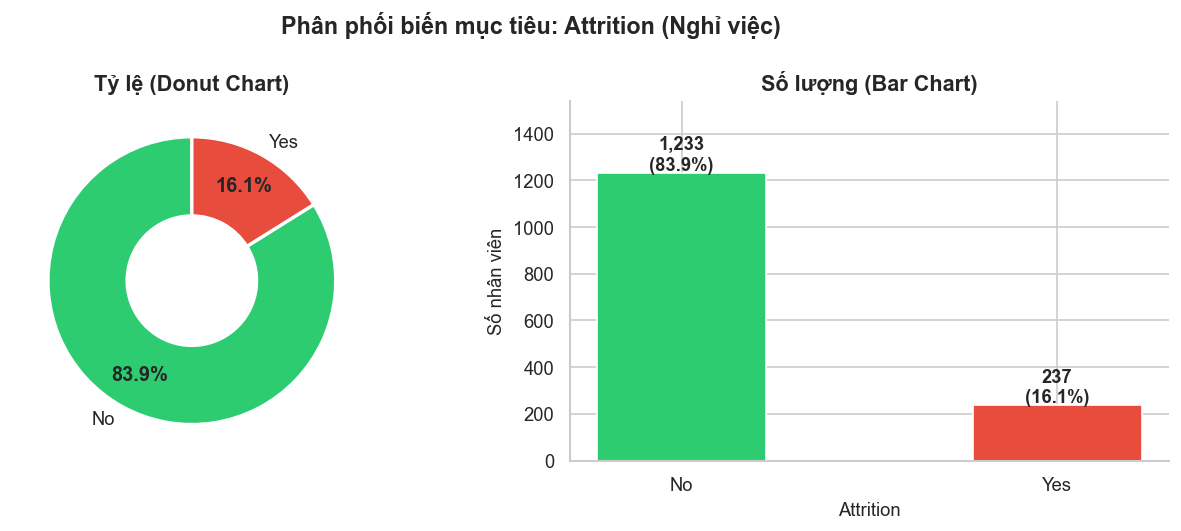

  Nhân viên vẫn đang làm (No) : 1,233  (83.9%)
  Nhân viên đã nghỉ việc (Yes): 237  (16.1%)


In [28]:
# PHÂN TÍCH BIẾN MỤC TIÊU (ATTRITION)
counts = df['Attrition'].value_counts()
pct    = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Phân phối biến mục tiêu: Attrition (Nghỉ việc)', fontsize=14, fontweight='bold')

# Donut chart
colors = [ATTRITION_COLORS[k] for k in counts.index]
wedges, texts, autotexts = axes[0].pie(
    counts, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Tỷ lệ (Donut Chart)')

# Bar chart
bars = axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.45)
for bar, val, p in zip(bars, counts.values, pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, counts.max() * 1.25)
axes[1].set_xlabel('Attrition'); axes[1].set_ylabel('Số nhân viên')
axes[1].set_title('Số lượng (Bar Chart)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print("=" * 50)
print(f"  Nhân viên vẫn đang làm (No) : {counts['No']:,}  ({pct['No']:.1f}%)")
print(f"  Nhân viên đã nghỉ việc (Yes): {counts['Yes']:,}  ({pct['Yes']:.1f}%)")
print("=" * 50)


=== Bảng thống kê mô tả — Biến định lượng ===


,Ý nghĩa,Min,Max,Mean,Median,Std
Age,Tuổi nhân viên,18.0,60.0,36.92,36.0,9.14
DailyRate,Hệ số lương ngày,102.0,1499.0,802.49,802.0,403.51
DistanceFromHome,Khoảng cách nhà → công ty (dặm),1.0,29.0,9.19,7.0,8.11
Education,Trình độ học vấn (1–5),1.0,5.0,2.91,3.0,1.02
EnvironmentSatisfaction,Hài lòng môi trường làm việc (1–4),1.0,4.0,2.72,3.0,1.09
HourlyRate,Hệ số lương giờ,30.0,100.0,65.89,66.0,20.33
JobInvolvement,Mức độ đầu tư vào công việc (1–4),1.0,4.0,2.73,3.0,0.71
JobLevel,Cấp bậc công việc (1–5),1.0,5.0,2.06,2.0,1.11
JobSatisfaction,Hài lòng công việc (1–4),1.0,4.0,2.73,3.0,1.10
MonthlyIncome,Thu nhập hàng tháng (USD),1009.0,19999.0,6502.93,4919.0,4707.96


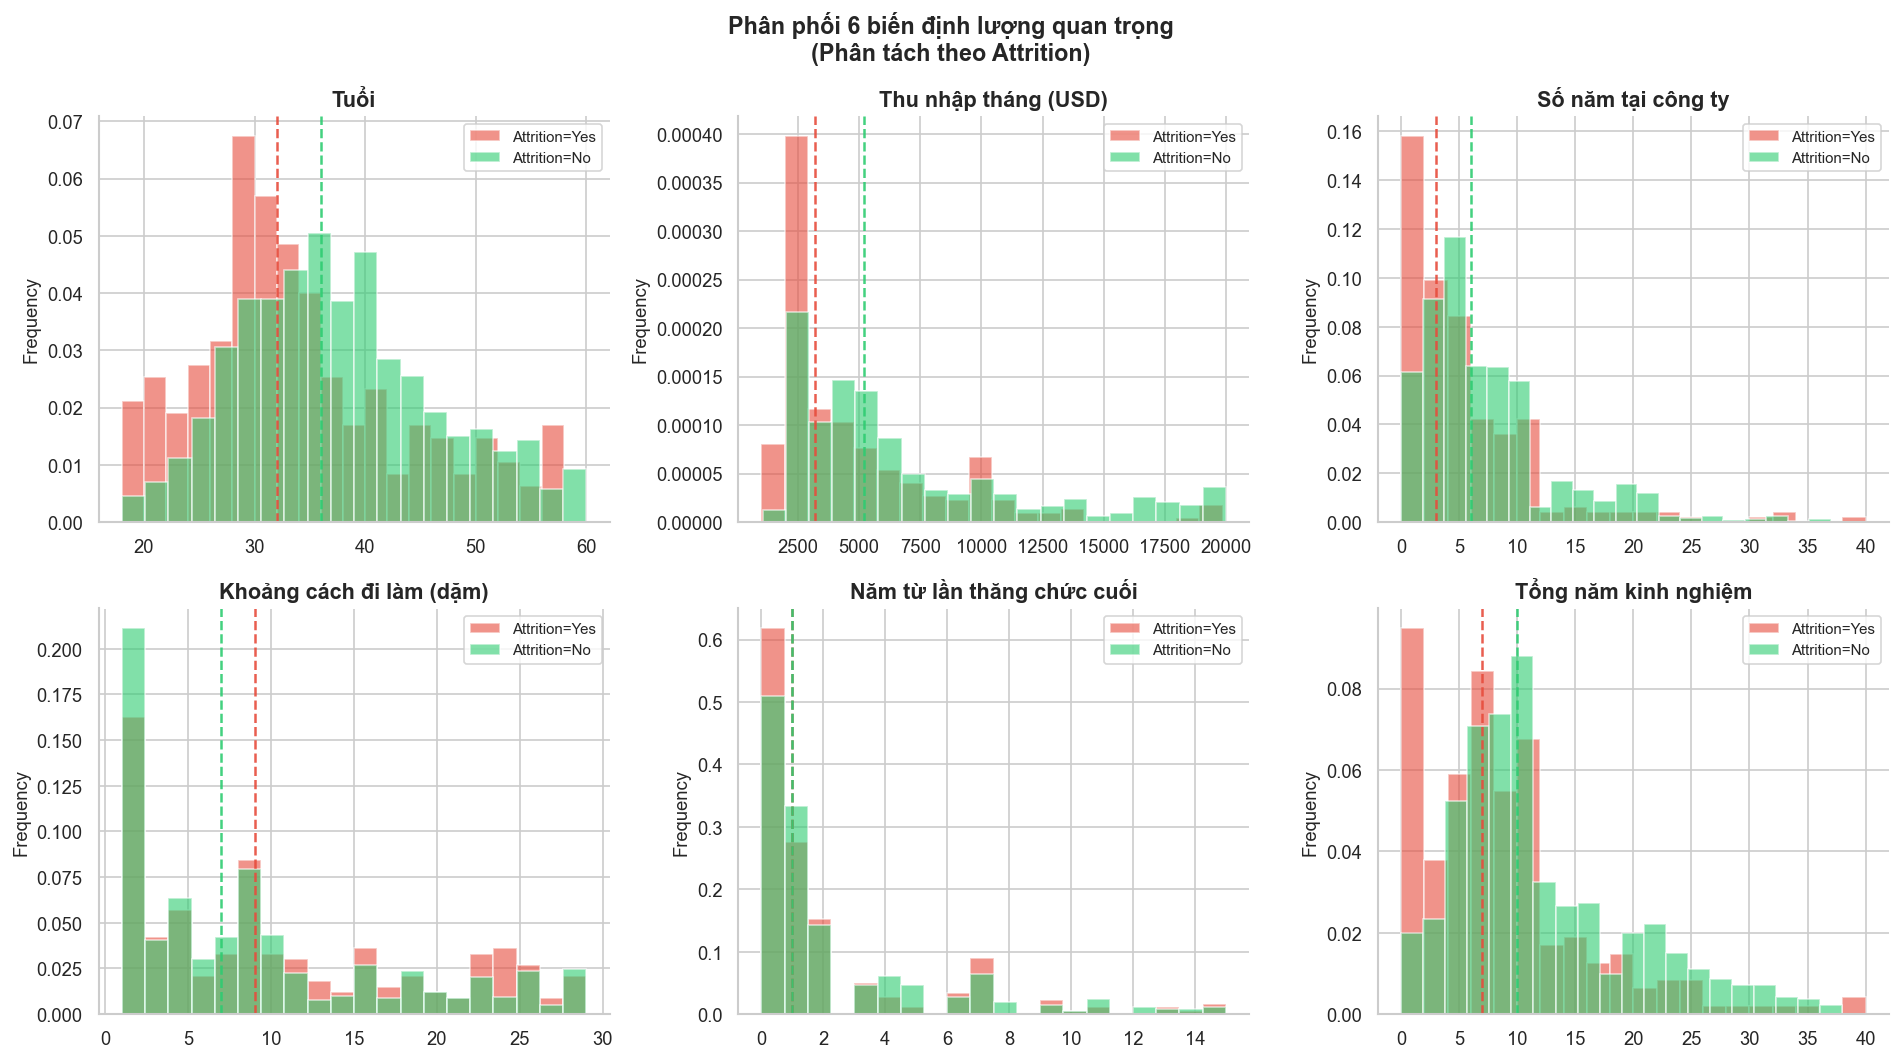

In [29]:
# PHÂN TÍCH BIẾN ĐỊNH LƯỢNG (NUMERICAL)
num_cols = df.select_dtypes(include='number').columns.tolist()

stats = df[num_cols].agg(['min', 'max', 'mean', 'median', 'std']).T
stats.columns = ['Min', 'Max', 'Mean', 'Median', 'Std']
stats = stats.round(2)

meaning_map = {
    'Age': 'Tuổi nhân viên', 'DailyRate': 'Hệ số lương ngày',
    'DistanceFromHome': 'Khoảng cách nhà → công ty (dặm)', 'Education': 'Trình độ học vấn (1–5)',
    'EnvironmentSatisfaction': 'Hài lòng môi trường làm việc (1–4)', 'HourlyRate': 'Hệ số lương giờ',
    'JobInvolvement': 'Mức độ đầu tư vào công việc (1–4)', 'JobLevel': 'Cấp bậc công việc (1–5)',
    'JobSatisfaction': 'Hài lòng công việc (1–4)', 'MonthlyIncome': 'Thu nhập hàng tháng (USD)',
    'MonthlyRate': 'Hệ số lương tháng', 'NumCompaniesWorked': 'Số công ty đã làm việc',
    'PercentSalaryHike': '% tăng lương gần nhất', 'PerformanceRating': 'Đánh giá hiệu suất (1–4)',
    'RelationshipSatisfaction': 'Hài lòng quan hệ đồng nghiệp (1–4)', 'StockOptionLevel': 'Quyền mua cổ phiếu (0–3)',
    'TotalWorkingYears': 'Tổng số năm làm việc', 'TrainingTimesLastYear': 'Số lần đào tạo năm ngoái',
    'WorkLifeBalance': 'Cân bằng công việc/cuộc sống (1–4)', 'YearsAtCompany': 'Số năm tại công ty này',
    'YearsInCurrentRole': 'Số năm ở vai trò hiện tại', 'YearsSinceLastPromotion': 'Số năm kể từ lần thăng chức cuối',
    'YearsWithCurrManager': 'Số năm với quản lý hiện tại',
}
stats['Ý nghĩa'] = stats.index.map(meaning_map)
stats = stats[['Ý nghĩa', 'Min', 'Max', 'Mean', 'Median', 'Std']]

print("\n=== Bảng thống kê mô tả — Biến định lượng ===")
display(stats)

# Vẽ 6 biến định lượng quan trọng nhất
key_num = {
    'Age': 'Tuổi', 'MonthlyIncome': 'Thu nhập tháng (USD)',
    'YearsAtCompany': 'Số năm tại công ty', 'DistanceFromHome': 'Khoảng cách đi làm (dặm)',
    'YearsSinceLastPromotion':'Năm từ lần thăng chức cuối', 'TotalWorkingYears': 'Tổng năm kinh nghiệm',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Phân phối 6 biến định lượng quan trọng\n(Phân tách theo Attrition)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (col, label) in enumerate(key_num.items()):
    ax = axes[i]
    for attrition_val, color in ATTRITION_COLORS.items():
        subset = df[df['Attrition'] == attrition_val][col]
        subset.plot.hist(ax=ax, bins=20, alpha=0.6, color=color, label=f'Attrition={attrition_val}', density=True)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    for attrition_val, color in ATTRITION_COLORS.items():
        med = df[df['Attrition'] == attrition_val][col].median()
        ax.axvline(med, color=color, linestyle='--', linewidth=1.5, alpha=0.9)

plt.tight_layout()
plt.show()

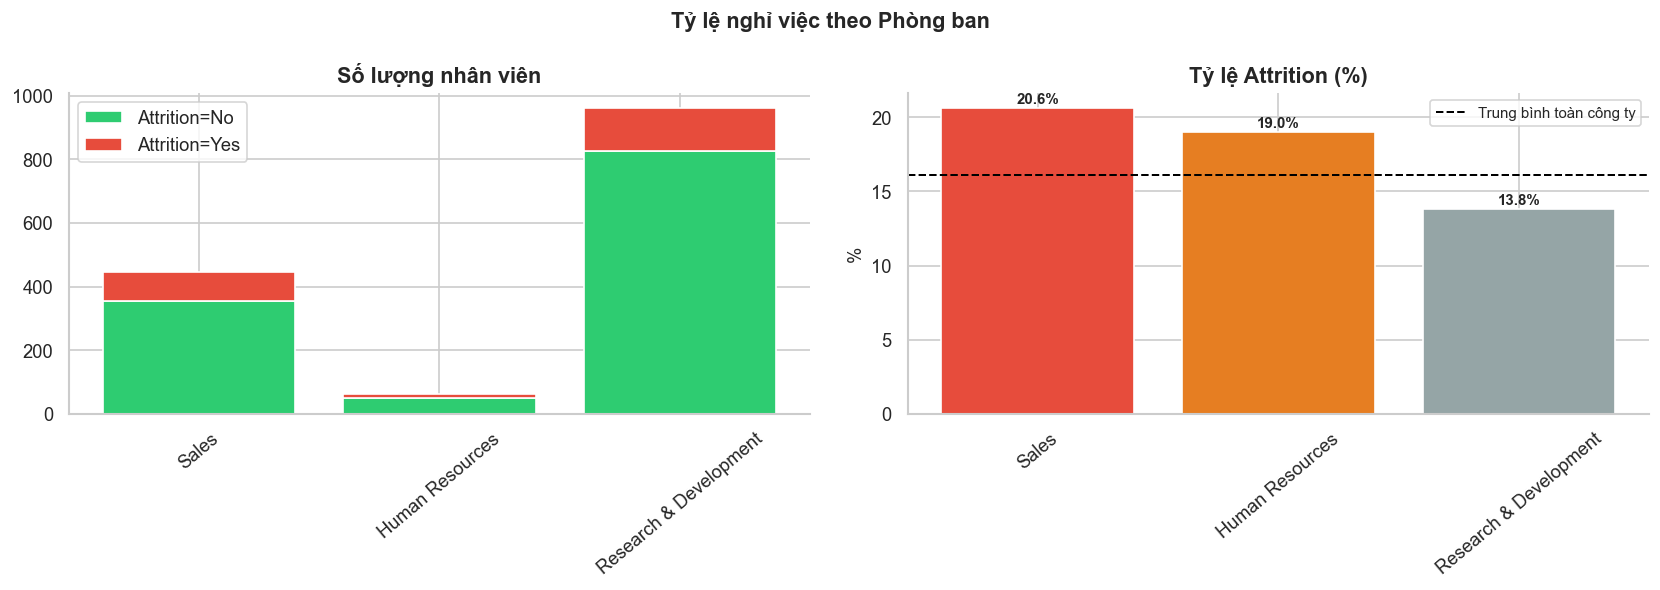

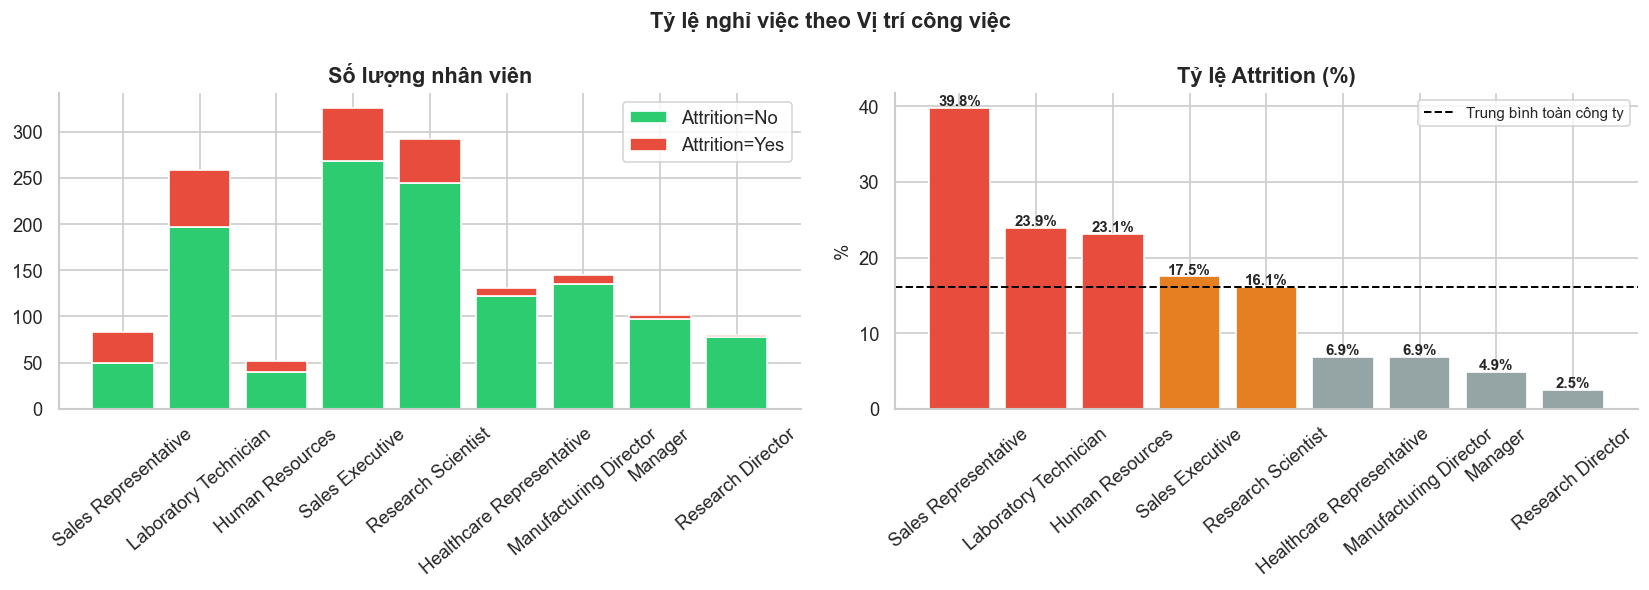

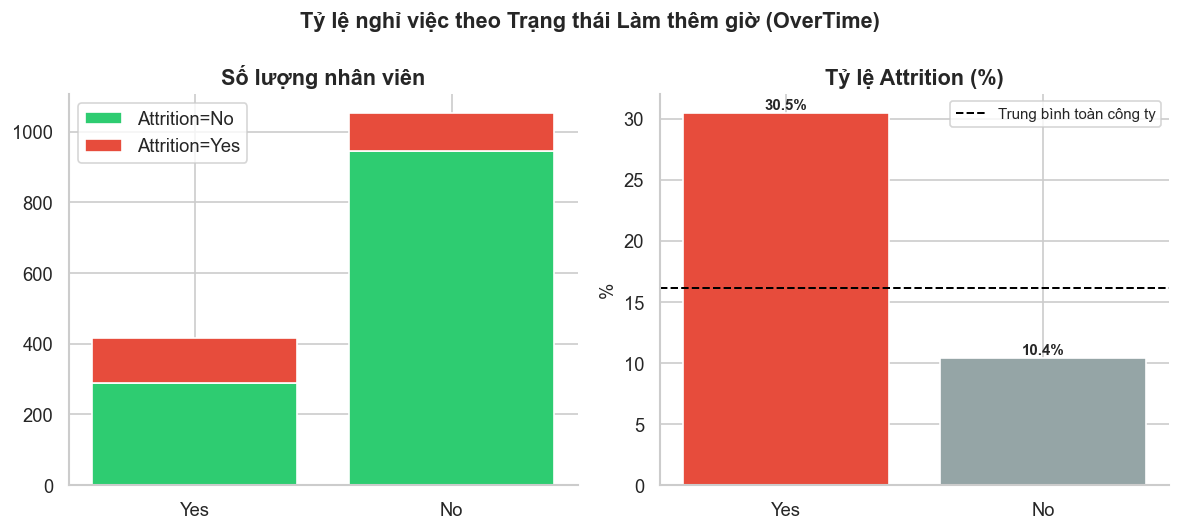

In [30]:
# PHÂN TÍCH BIẾN ĐỊNH TÍNH (CATEGORICAL)

# Hàm tính và vẽ biểu đồ tỷ lệ nghỉ việc theo nhóm
def plot_attrition_rate(col, title, figsize=(10, 4.5), rotate=0):
    group = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    group['Total'] = group.sum(axis=1)
    group['Attrition_Rate'] = (group.get('Yes', 0) / group['Total'] * 100).round(1)
    group = group.sort_values('Attrition_Rate', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(title, fontsize=13, fontweight='bold')

    bottom = np.zeros(len(group))
    for attrition_val, color in [('No', '#2ECC71'), ('Yes', '#E74C3C')]:
        if attrition_val in group.columns:
            axes[0].bar(group.index, group[attrition_val], bottom=bottom,
                        color=color, label=f'Attrition={attrition_val}', edgecolor='white')
            bottom += group[attrition_val].values
    axes[0].set_title('Số lượng nhân viên')
    axes[0].legend()
    axes[0].spines[['top','right']].set_visible(False)
    if rotate: axes[0].tick_params(axis='x', rotation=rotate)

    bar_colors = ['#E74C3C' if r >= 20 else '#E67E22' if r >= 15 else '#95A5A6' for r in group['Attrition_Rate']]
    bars = axes[1].bar(group.index, group['Attrition_Rate'], color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, group['Attrition_Rate']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1].axhline(y=df['Attrition'].eq('Yes').mean()*100, color='black', linestyle='--', linewidth=1.2, label='Trung bình toàn công ty')
    axes[1].set_title('Tỷ lệ Attrition (%)')
    axes[1].set_ylabel('%')
    axes[1].legend(fontsize=9)
    axes[1].spines[['top','right']].set_visible(False)
    if rotate: axes[1].tick_params(axis='x', rotation=rotate)

    plt.tight_layout()
    plt.show()

# Biểu đồ cho Department, JobRole, OverTime
plot_attrition_rate('Department', 'Tỷ lệ nghỉ việc theo Phòng ban',figsize=(14, 5), rotate=40)
plot_attrition_rate('JobRole', 'Tỷ lệ nghỉ việc theo Vị trí công việc', figsize=(14, 5), rotate=40)
plot_attrition_rate('OverTime', 'Tỷ lệ nghỉ việc theo Trạng thái Làm thêm giờ (OverTime)')

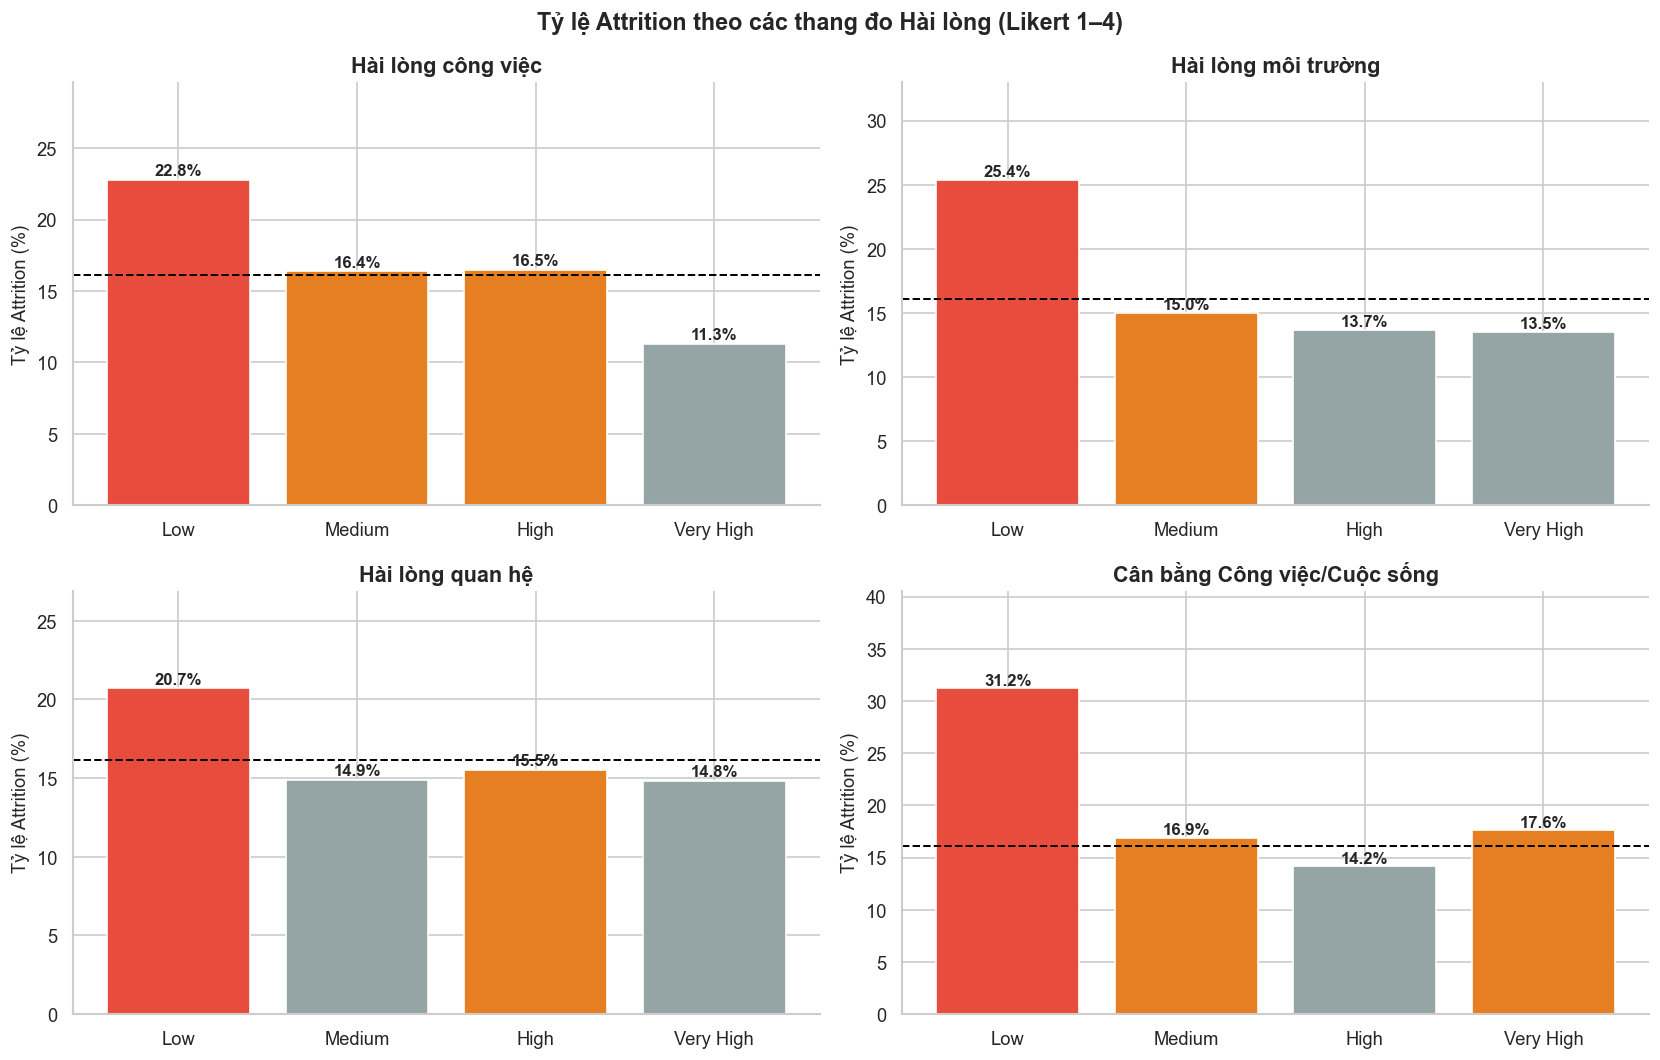

In [31]:
# PHÂN TÍCH BIẾN SATISFACTION (Likert 1-4)
satisfaction_cols = {
    'JobSatisfaction': 'Hài lòng công việc', 'EnvironmentSatisfaction': 'Hài lòng môi trường',
    'RelationshipSatisfaction': 'Hài lòng quan hệ', 'WorkLifeBalance': 'Cân bằng Công việc/Cuộc sống',
}
scale_labels = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Tỷ lệ Attrition theo các thang đo Hài lòng (Likert 1–4)', fontsize=14, fontweight='bold')
axes = axes.flatten()

avg_rate = df['Attrition'].eq('Yes').mean() * 100

for i, (col, label) in enumerate(satisfaction_cols.items()):
    ax = axes[i]
    group = df.groupby(col)['Attrition'].apply(lambda x: (x=='Yes').mean()*100).round(1)
    group.index = [scale_labels.get(k, k) for k in group.index]

    bar_colors = ['#E74C3C' if v >= 20 else '#E67E22' if v >= 15 else '#95A5A6' for v in group.values]
    bars = ax.bar(group.index, group.values, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, group.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(y=avg_rate, color='black', linestyle='--', linewidth=1.2, label=f'Trung bình ({avg_rate:.1f}%)')
    ax.set_title(label)
    ax.set_ylabel('Tỷ lệ Attrition (%)')
    ax.set_ylim(0, group.max() * 1.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

**BẢNG TỔNG HỢP INSIGHTS: Thống kê mô tả & Phân tích đơn biến**

| ID | Biến liên quan (Feature) | Phát biểu (Insights từ Biểu đồ) | Ý nghĩa thực tiễn / Khuyến nghị |
|:---:|:---|:---|:---|
| **S1** | **Tuổi** <br>*(Age)* | Nhân viên nghỉ việc tập trung mật độ rất cao ở nhóm tuổi trẻ **(20–30 tuổi)**. Từ sau 30 tuổi, tỷ lệ nghỉ giảm dần. | Lực lượng lao động trẻ thường chưa ổn định định hướng. HR cần xây dựng lộ trình nghề nghiệp rõ ràng và các chương trình Mentorship. |
| **S2** | **Thu nhập tháng** <br>*(MonthlyIncome)* | Tỷ lệ Attrition đặc biệt cao ở phân khúc **lương thấp (<$5.000)**. Thu nhập tăng thì tỷ lệ nghỉ việc giảm mạnh. | Lương thưởng là yếu tố đẩy trọng yếu. Cần rà soát và review lương định kỳ, đặc biệt chú ý đến nhân viên cấp thấp/mới vào làm. |
| **S3** | **Số năm tại công ty** <br>*(YearsAtCompany)* | Tỷ lệ nghỉ việc cao nhất rơi vào những nhân viên có thâm niên thấp, đặc biệt là **dưới 5 năm**. | Giai đoạn đầu làm việc rất dễ nản chí. Cần tập trung cải thiện chất lượng chương trình hội nhập để giữ chân nhân viên mới. |
| **S4** | **Khoảng cách đi làm** <br>*(DistanceFromHome)* | Khoảng cách di chuyển càng xa, tỷ lệ nghỉ việc có xu hướng nhích lên thê hiện ở các cột màu đỏ xuất hiện nhiều hơn ở dải >10 dặm. | Di chuyển xa gây mệt mỏi. Có thể cân nhắc chính sách làm việc linh hoạt hoặc hỗ trợ chi phí đi lại. |
| **S5** | **Năm từ lần thăng chức** <br>*(YearsSinceLastPromotion)* | Khá thú vị là nhân viên nghỉ nhiều ở mốc **0-1 năm** và có dấu hiệu tăng lại ở những người **lâu không được thăng chức**. | Cần đánh giá lại kỳ vọng/áp lực ngay sau khi nhân viên được thăng chức, đồng thời không bỏ quên những nhân viên lâu năm. |
| **S6** | **Tổng năm kinh nghiệm** <br>*(TotalWorkingYears)* | Tương đồng với biến Tuổi, tỷ lệ nghỉ cao vượt trội ở nhóm có ít năm kinh nghiệm **(0–5 năm)**. | Nhóm chưa có nhiều kinh nghiệm dễ gặp shock văn hóa công sở. Cần hướng dẫn và đào tạo kỹ năng mềm sát sao hơn. |
| **S7** | **Phòng ban** <br>*(Department)* | **Sales** có tỷ lệ nghỉ việc cao nhất (20.6%), tiếp theo là Human Resources (19.0%), cao hơn mức trung bình công ty (16.1%). | Đặc thù ngành Sales có áp lực doanh số lớn. Cần tìm hiểu sâu hơn về văn hóa và cơ chế tính KPI của phòng ban này. |
| **S8** | **Vị trí công việc** <br>*(JobRole)* | **Sales Representative** có tỷ lệ nghỉ việc cao đột biến **(39.8%)**, theo sau là Lab Technician (23.9%) và HR (23.1%). | Vị trí Sales Rep đang đối mặt với rủi ro nhân sự rất lớn. Cần khẩn trương đánh giá lại đãi ngộ và tính khả thi của khối lượng công việc. |
| **S9** | **Làm thêm giờ** <br>*(OverTime)* | Nhân viên làm thêm giờ (Yes) có tỷ lệ nghỉ việc **(30.5%) cao gấp ~3 lần** so với nhóm không làm thêm giờ (10.4%). | Làm thêm giờ mãn tính là tín hiệu dự báo nghỉ việc cực kỳ mạnh do kiệt sức (burnout). Khuyến nghị kiểm soát nghiêm ngặt giờ OT. |
| **S10** | **Các thang đo Hài lòng** <br>*(Satisfaction & WLB)* | Điểm đánh giá **"Low" (Mức 1)** ở mọi thang đo đều đi kèm tỷ lệ nghỉ việc rất cao, đặc biệt là **Cân bằng Công việc/Cuộc sống (31.2%)**. | Yếu tố tâm lý tác động trực tiếp đến quyết định rời đi. Khuyến nghị HR đẩy mạnh các phúc lợi mềm, tôn trọng thời gian cá nhân của nhân viên. |



# 3. Mã hóa biến định tính & Tạo `df_encoded`
---


Để thực hiện phân tích tương quan và chuẩn bị dữ liệu cho mô hình, chúng ta cần chuyển đổi các biến định tính kiểu `object` thành định lượng.

*   **One-Hot Encoding** cho các biến định tính.
*   Tạo biến `Attrition_bin` từ `Attrition` (Yes=1, No=0) để tính toán tương quan.

In [32]:
# Định nghĩa màu sắc cho biểu đồ
C_NO     = '#2ECC71'  # Xanh lá: Không nghỉ
C_YES    = '#E74C3C'  # Đỏ: Nghỉ
C_ORANGE = '#E67E22'  # Cam: Rủi ro trung bình
C_AVG    = '#34495E'  # Xám đậm: Trung bình toàn công ty

# Tạo bản sao của DataFrame để tính toán tỷ lệ nghỉ việc
df_encoded = df.copy()

# CHỈ chuyển đổi biến mục tiêu 'Attrition' sang dạng nhị phân (1=Nghỉ, 0=Ở lại) để dễ tính %
df_encoded['Attrition_bin'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

print("Đã tạo df_encoded thành công!")
print("Các cột hiện có:", df_encoded.columns.tolist())


Đã tạo df_encoded thành công!
Các cột hiện có: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_bin']


## 3.1 Correlation Heatmap — "Bản đồ nhiệt" mối quan hệ giữa các biến

> Để biết được biến nào thực sự liên quan đến Nguy cơ nghỉ việc để ưu tiên phân tích và loại bỏ được các biến tương quan cao tránh nguy cơ đa cộng tuyến thì ta tiến hành vẽ Correlation heatmap.


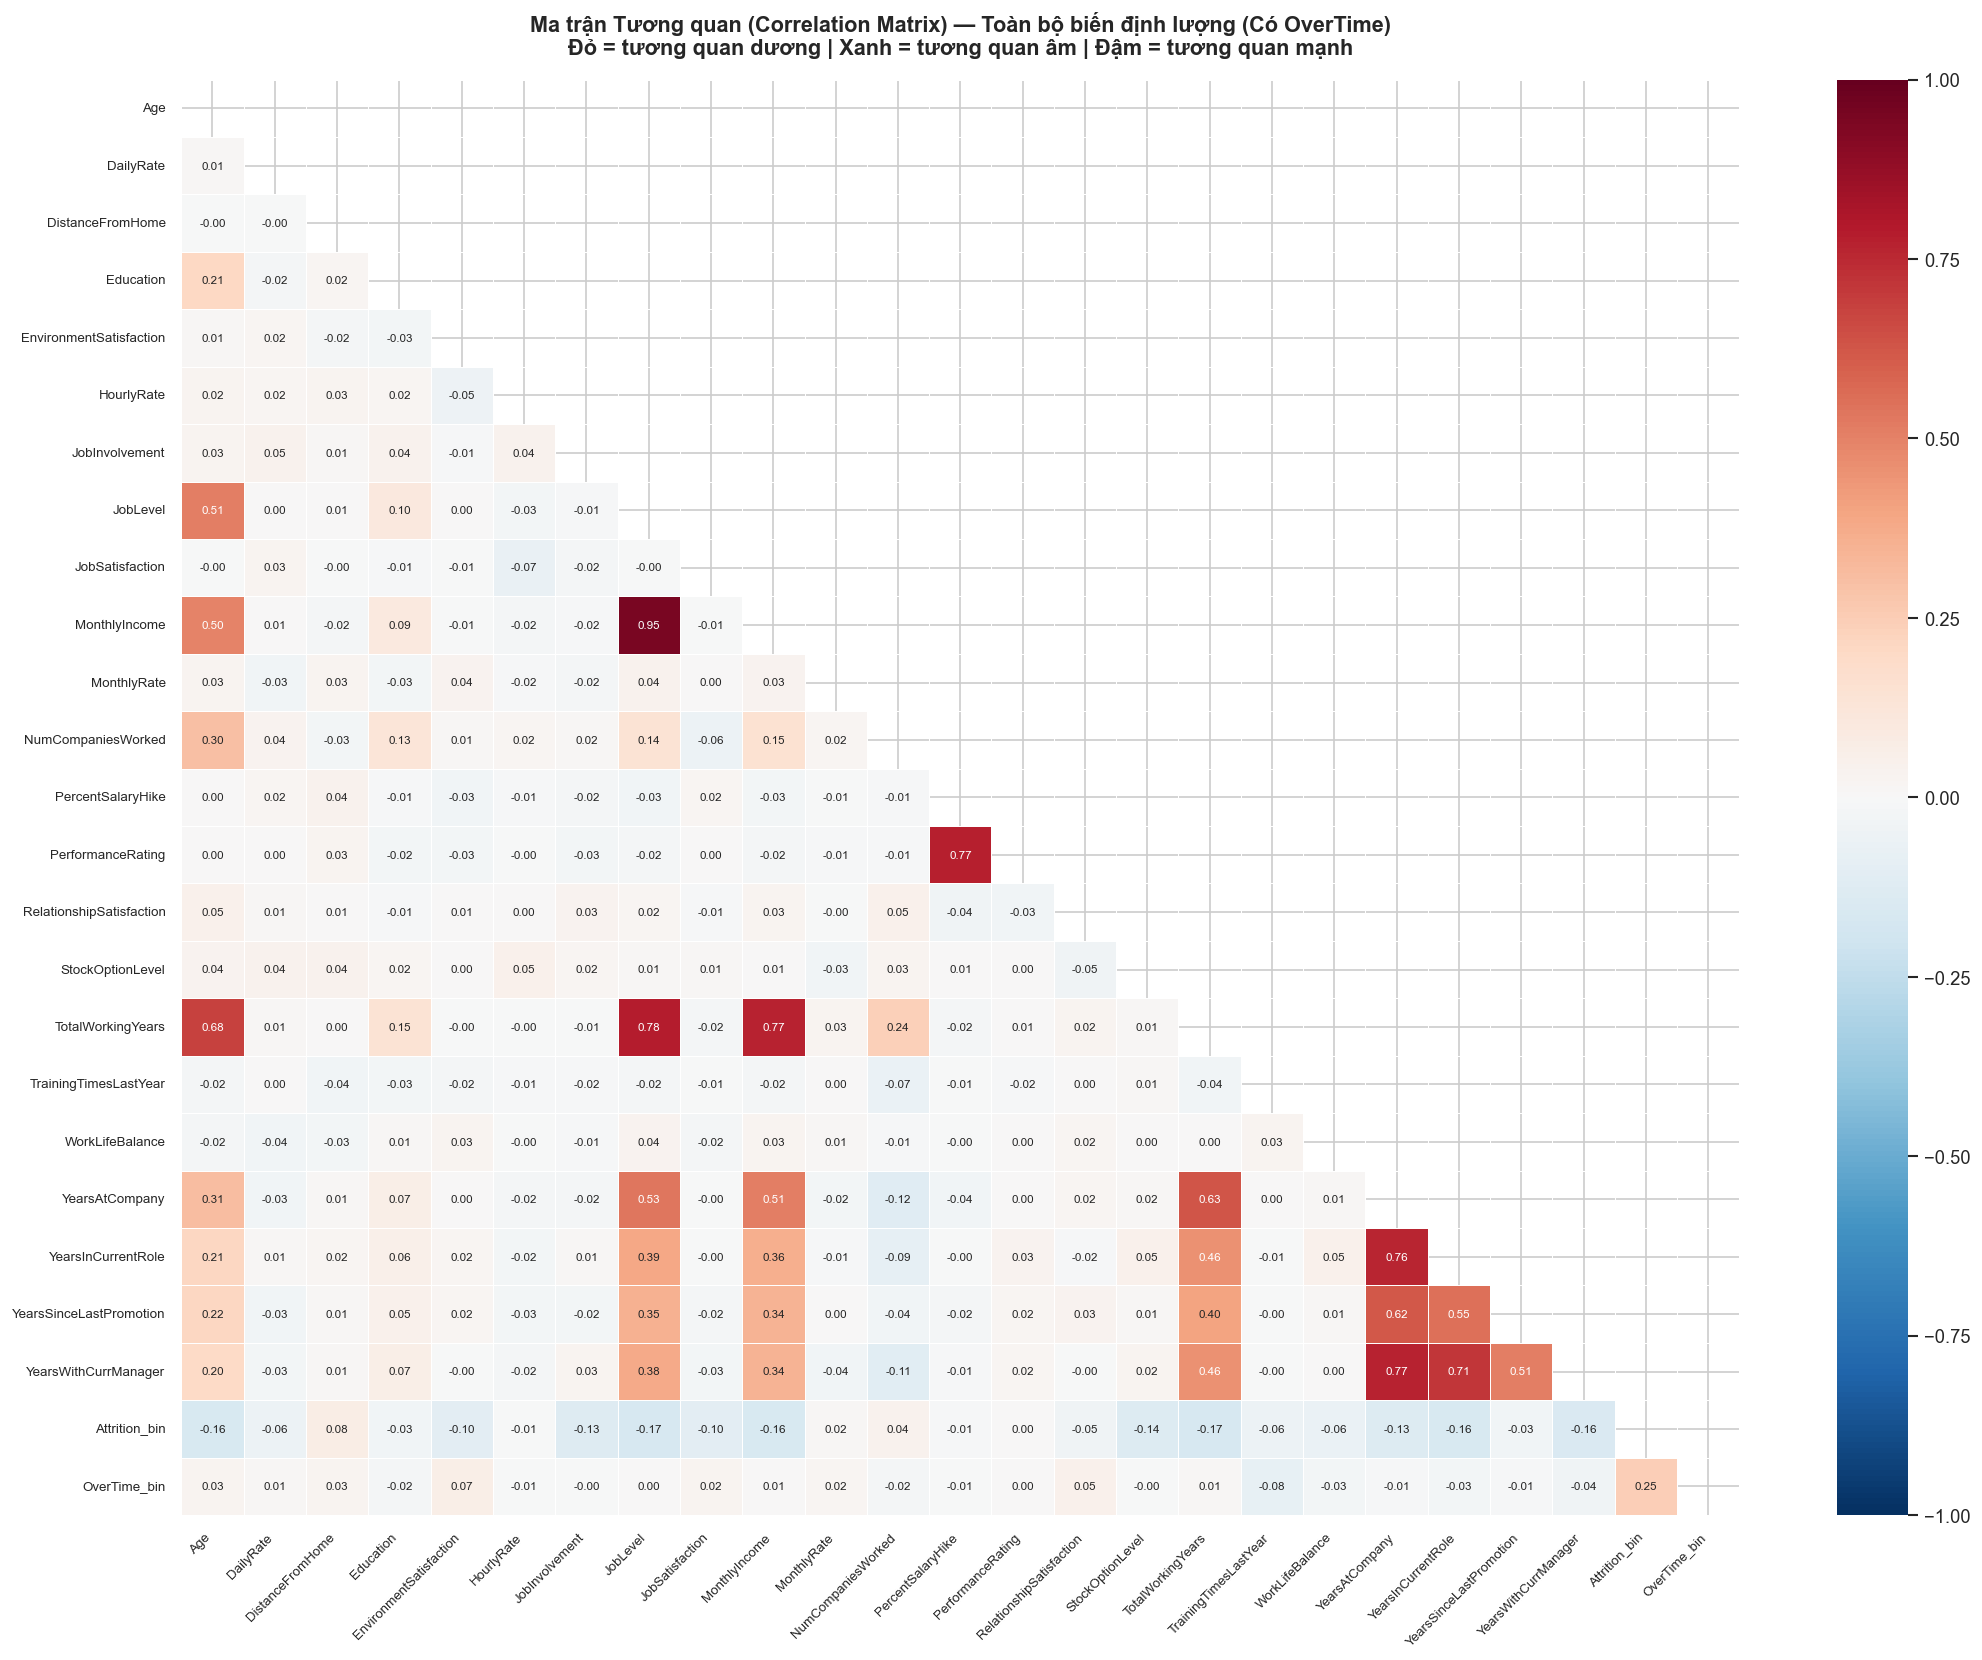

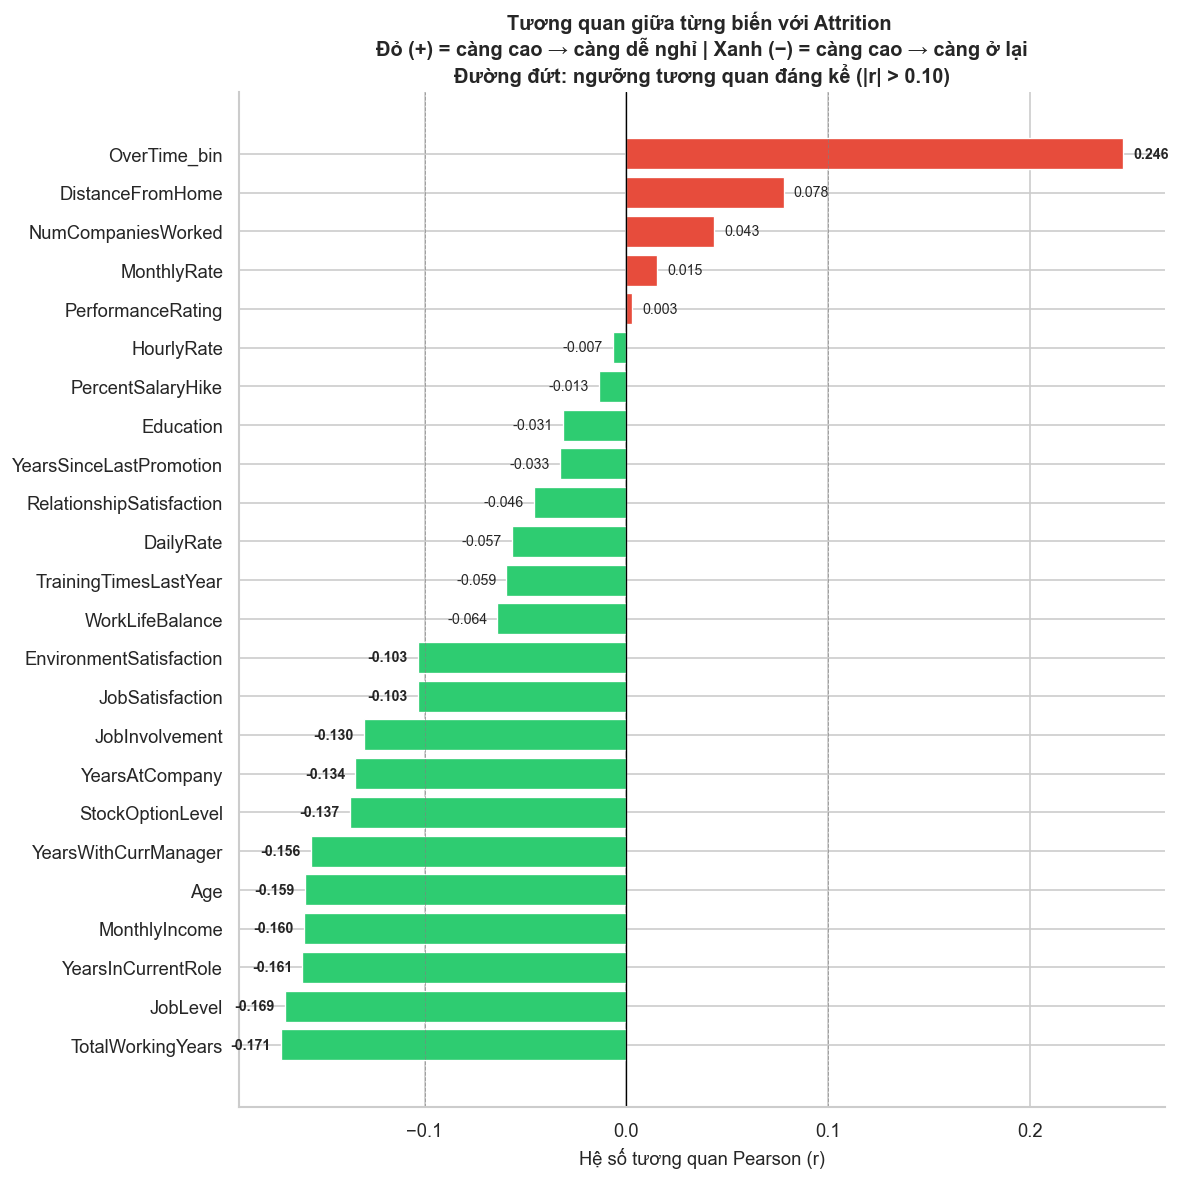


=== Top 5 biến TƯƠNG QUAN DƯƠNG với Attrition  ===
PerformanceRating     0.002889
MonthlyRate           0.015170
NumCompaniesWorked    0.043494
DistanceFromHome      0.077924
OverTime_bin          0.246118

=== Top 5 biến TƯƠNG QUAN ÂM với Attrition ===
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205


In [33]:
# 3.1: CORRELATION HEATMAP 

# 1. Tạo bản sao tạm thời và ép kiểu OverTime sang số (1/0)
df_corr = df_encoded.copy()
df_corr['OverTime_bin'] = df_corr['OverTime'].map({'Yes': 1, 'No': 0})

# 2. Tính ma trận tương quan cho tất cả biến số
num_cols = df_corr.select_dtypes(include='number').columns.tolist()
corr_matrix = df_corr[num_cols].corr()

# 3. Vẽ HeatMap 
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # chỉ vẽ nửa dưới
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 7}, ax=ax
)
ax.set_title(
    'Ma trận Tương quan (Correlation Matrix) — Toàn bộ biến định lượng (Có OverTime)\n'
    'Đỏ = tương quan dương | Xanh = tương quan âm | Đậm = tương quan mạnh',
    fontsize=13, pad=15
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# 4. Tập trung vào biến tương quan với Attrition
attrition_corr = corr_matrix['Attrition_bin'].drop('Attrition_bin').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = [C_YES if v > 0 else C_NO for v in attrition_corr.values]
bars = ax.barh(attrition_corr.index, attrition_corr.values, color=colors,
               edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, attrition_corr.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8.5,
            fontweight='bold' if abs(val) > 0.1 else 'normal')

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.1, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
ax.axvline(-0.1, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_title(
    'Tương quan giữa từng biến với Attrition \n'
    'Đỏ (+) = càng cao → càng dễ nghỉ | Xanh (−) = càng cao → càng ở lại\n'
    'Đường đứt: ngưỡng tương quan đáng kể (|r| > 0.10)',
    fontsize=12
)
ax.set_xlabel('Hệ số tương quan Pearson (r)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── 5. IN KẾT QUẢ TOP 5 ──
print('\n=== Top 5 biến TƯƠNG QUAN DƯƠNG với Attrition  ===')
print(attrition_corr.tail(5).to_string())
print('\n=== Top 5 biến TƯƠNG QUAN ÂM với Attrition ===')
print(attrition_corr.head(5).to_string())

**Phân tích & Phát biểu — Correlation Heatmap**

- Màu **đỏ nhạt/đậm (Tương quan Dương)**: Biến càng tăng → Nhân viên càng **dễ nghỉ việc hơn (Yếu tố đẩy - Push Factors)**.
- Màu **xanh nhạt/đậm (Tương quan Âm)**: Biến càng tăng → Nhân viên càng **có xu hướng ở lại (Yếu tố giữ - Pull/Retention Factors)**.
- Ngưỡng **|r| > 0.10** được coi là **đáng kể** trong dữ liệu HR thực tế.

**Phát biểu rút ra:**

| Nhóm | Biến | r | Ý nghĩa kinh doanh (Business Insights) |
|---|---|:---:|---|
| **Yếu tố đẩy** | OverTime | **+0.25** | **Biến đơn lẻ mạnh nhất** thúc đẩy Attrition. Làm thêm giờ gây kiệt sức. Đây là yếu tố duy nhất qua ngưỡng >0.10. |
| **Yếu tố đẩy** | DistanceFromHome | +0.08 | Đi làm xa gây mệt mỏi. Dù chưa qua ngưỡng 0.10 nhưng kết hợp với yếu tố khác như OT sẽ tạo thành rủi ro lớn. |
| **Yếu tố đẩy** | NumCompaniesWorked | +0.04 | Lịch sử nhảy việc nhiều báo hiệu tính cách ít gắn bó lâu dài. Tương quan yếu. |
| **Yếu tố đẩy** | MonthlyRate | +0.02 | Tương quan vô cùng yếu, gần như không có tác động thực tế đến quyết định nghỉ việc. |
| **Yếu tố đẩy** | PerformanceRating | ~0.00 | Đánh giá hiệu suất hoàn toàn không phải là nguyên nhân khiến nhân viên rời đi. |
| **Yếu tố giữ** | TotalWorkingYears | **−0.17** | **Yếu tố giữ chân mạnh nhất.** Kinh nghiệm thị trường càng nhiều, nhân viên càng mong muốn sự ổn định. |
| **Yếu tố giữ** | JobLevel | **−0.17** | Lên được vị trí cấp cao  $\rightarrow$ đãi ngộ tốt, quyền lực cao $\rightarrow$ Tỷ lệ nghỉ giảm mạnh. |
| **Yếu tố giữ** | YearsInCurrentRole | **−0.16** | Làm càng lâu ở một vị trí $\rightarrow$ đã quen việc, quen môi trường $\rightarrow$ hình thành thói quen với môi trường ngại thay đổi. |
| **Yếu tố giữ** | MonthlyIncome | **−0.16** | Lương thưởng cao triệt tiêu động lực tìm kiếm công việc mới vì mục đích tài chính. |
| **Yếu tố giữ** | Age | **−0.16** | Tuổi đời càng cao $\rightarrow$ gánh nặng gia đình/tâm lý ổn định $\rightarrow$ ít có xu hướng mạo hiểm nhảy việc. |

> **Insight cốt lõi:** 
> - **Về Yếu tố đẩy:** `OverTime` là "ngòi nổ" duy nhất thực sự đáng kể (|r| = 0.25). Quãng đường đi làm hay lịch sử nhảy việc chỉ đóng vai trò phụ trợ.
> - **Về Yếu tố giữ:** Đáng chú ý là cả 5 Yếu tố giữ là Kinh nghiệm, Cấp bậc, Thời gian tại vị trí, Thu nhập và Tuổi đều vượt ngưỡng đáng kể **(|r| > 0.15)**. Điều này cho thấy công ty đang làm rất tốt việc giữ chân nhóm "Lão làng" (người lớn tuổi, cấp cao, lương cao).
> - **Kết luận:** Attrition **không do một nguyên nhân duy nhất** — đây là hậu quả tích lũy của nhiều yếu tố. Bộ phận HR cần nhìn vào **tổ hợp** các yếu tố, không phải từng biến riêng lẻ. Đó là lý do Bước 3 này sẽ tiến hành phân tích sự tương tác chéo (Interaction) giữa các biến với nhau.


---
## 3.2 Kiểm chứng Giả thuyết #1: OverTime × Thu nhập × Attrition

> **Giả thuyết cần kiểm chứng:** *"Nhân viên vừa làm thêm giờ vừa có thu nhập thấp là nhóm có nguy cơ nghỉ việc cao nhất đây là bẫy 'cống nạp mà không được đền bù'."*


C:\Users\Acer\AppData\Local\Temp\ipykernel_28480\1442307971.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_encoded.groupby(['IncomeTier', 'OverTime'])['Attrition_bin'].mean().unstack() * 100


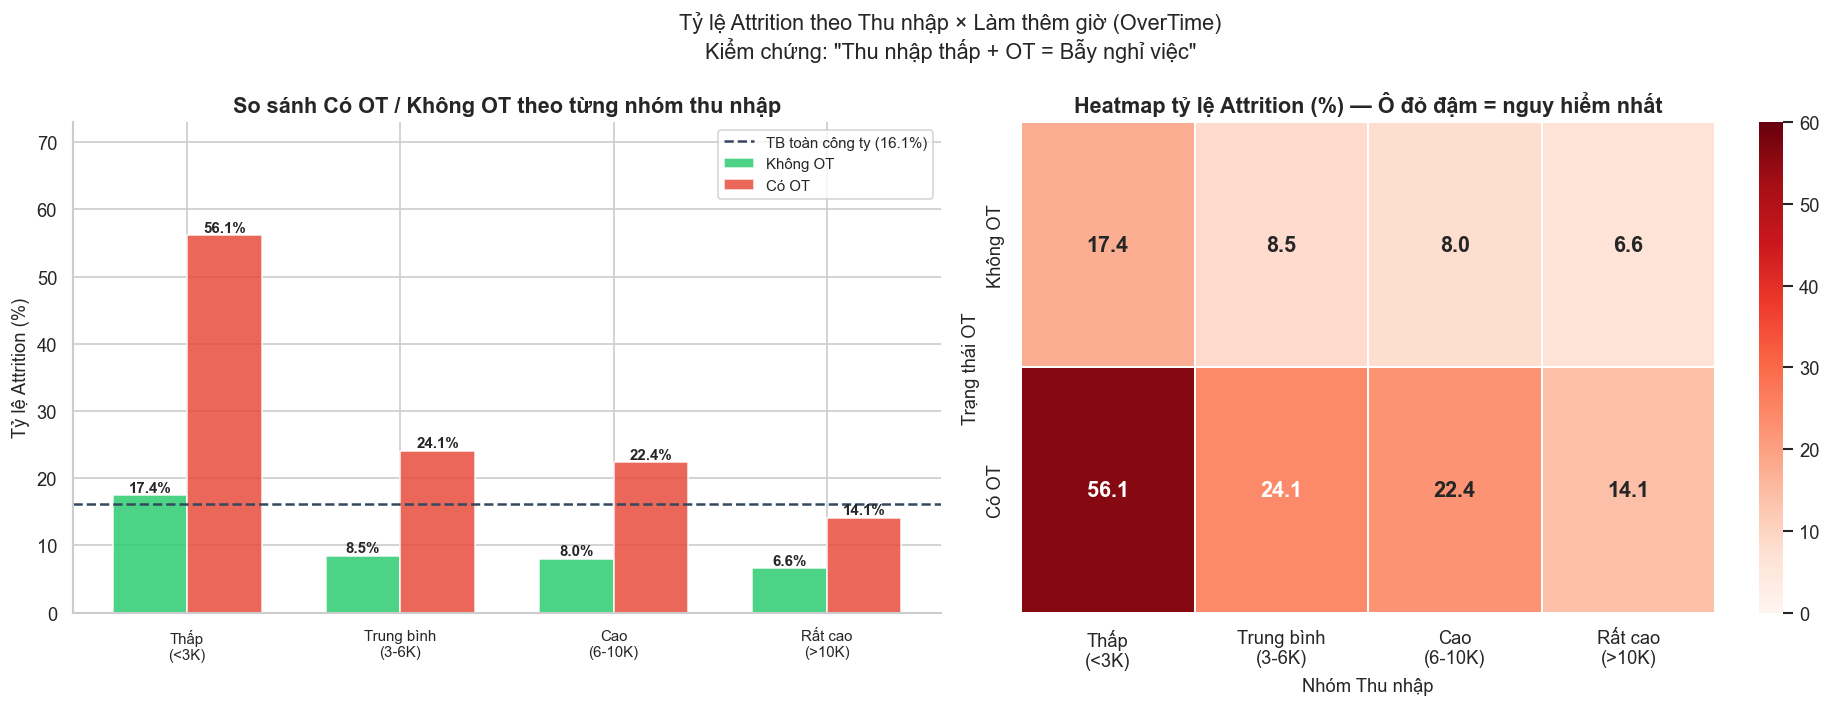

=== Bảng tỷ lệ Attrition (%) theo OT × Thu nhập ===


,Không OT,Có OT
Thấp (<3K),17.4,56.1
Trung bình (3-6K),8.5,24.1
Cao (6-10K),8.0,22.4
Rất cao (>10K),6.6,14.1



 Nhóm nguy hiểm nhất (Thu nhập thấp + OT): 56.1%
 Nhóm an toàn nhất (Thu nhập cao + Không OT): 6.6%
 Chênh lệch: 8.5x — Nhóm nguy hiểm có rủi ro cao hơn 8.5 lần


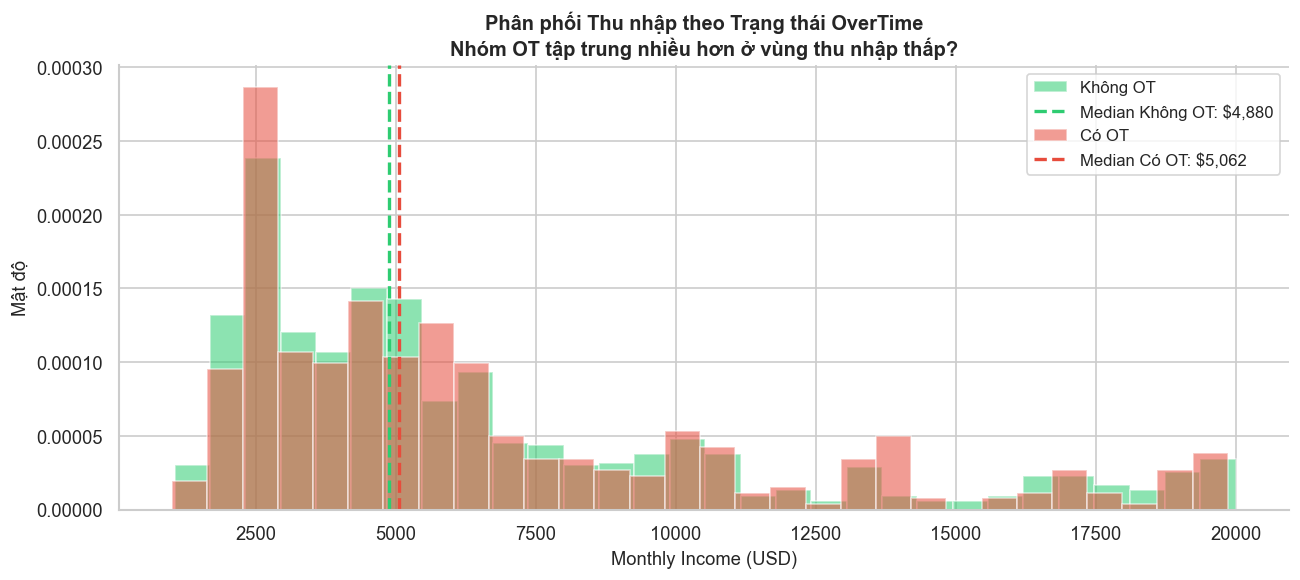

Median thu nhập nhóm CÓ OT   : $5,062
Median thu nhập nhóm KHÔNG OT: $4,880
Chênh lệch: $-182 — Nhóm OT kiếm ít hơn $-182/tháng


In [39]:
# Tạo nhóm thu nhập
df_encoded['IncomeTier'] = pd.cut(
    df_encoded['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 999999],
    labels=['Thấp\n(<3K)', 'Trung bình\n(3-6K)', 'Cao\n(6-10K)', 'Rất cao\n(>10K)']
)

# Tính tỷ lệ Attrition theo OT × IncomeTier 
pivot = df_encoded.groupby(['IncomeTier', 'OverTime'])['Attrition_bin'].mean().unstack() * 100
pivot.columns = ['Không OT', 'Có OT']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Tỷ lệ Attrition theo Thu nhập × Làm thêm giờ (OverTime)\n'
    'Kiểm chứng: "Thu nhập thấp + OT = Bẫy nghỉ việc"',
    fontsize=13
)

# Biểu đồ 1: Grouped bar
ax1 = axes[0]
x = np.arange(len(pivot.index))
w = 0.35
b1 = ax1.bar(x - w/2, pivot['Không OT'], w, label='Không OT', color=C_NO, alpha=0.85, edgecolor='white')
b2 = ax1.bar(x + w/2, pivot['Có OT'],    w, label='Có OT',    color=C_YES, alpha=0.85, edgecolor='white')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
             ha='center', fontsize=9, fontweight='bold')
avg = df_encoded['Attrition_bin'].mean() * 100
ax1.axhline(avg, color=C_AVG, linestyle='--', linewidth=1.5, label=f'TB toàn công ty ({avg:.1f}%)')
ax1.set_xticks(x)
ax1.set_xticklabels(pivot.index, fontsize=9)
ax1.set_ylabel('Tỷ lệ Attrition (%)')
ax1.set_title('So sánh Có OT / Không OT theo từng nhóm thu nhập')
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(pivot.max()) * 1.3)
ax1.spines[['top','right']].set_visible(False)

# Biểu đồ 2: Heatmap tỷ lệ
ax2 = axes[1]
sns.heatmap(
    pivot.T, annot=True, fmt='.1f', cmap='Reds',
    linewidths=1, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    ax=ax2, vmin=0, vmax=60
)
ax2.set_title('Heatmap tỷ lệ Attrition (%) — Ô đỏ đậm = nguy hiểm nhất')
ax2.set_xlabel('Nhóm Thu nhập')
ax2.set_ylabel('Trạng thái OT')
plt.tight_layout()
plt.show()

print('=== Bảng tỷ lệ Attrition (%) theo OT × Thu nhập ===')

pivot_display = pivot.round(1).copy()
pivot_display.index = [str(idx).replace('\n', ' ') for idx in pivot_display.index]

display(pivot_display)


# Tính bội số rủi ro
low_ot_yes  = pivot.loc['Thấp\n(<3K)', 'Có OT']
high_ot_no  = pivot.loc['Rất cao\n(>10K)', 'Không OT']
print(f'\n Nhóm nguy hiểm nhất (Thu nhập thấp + OT): {low_ot_yes:.1f}%')
print(f' Nhóm an toàn nhất (Thu nhập cao + Không OT): {high_ot_no:.1f}%')
print(f' Chênh lệch: {low_ot_yes/high_ot_no:.1f}x — Nhóm nguy hiểm có rủi ro cao hơn {low_ot_yes/high_ot_no:.1f} lần')

# ── Phân phối thu nhập của từng nhóm OT ──
fig, ax = plt.subplots(figsize=(11, 5))
for ot_val, color, label in [('No', C_NO, 'Không OT'), ('Yes', C_YES, 'Có OT')]:
    subset = df_encoded[df_encoded['OverTime'] == ot_val]['MonthlyIncome']
    ax.hist(subset, bins=30, alpha=0.55, color=color, label=label, density=True)
    ax.axvline(subset.median(), color=color, linestyle='--', linewidth=2,
               label=f'Median {label}: ${subset.median():,.0f}')

ax.set_title(
    'Phân phối Thu nhập theo Trạng thái OverTime\n'
    'Nhóm OT tập trung nhiều hơn ở vùng thu nhập thấp?',
    fontsize=12
)
ax.set_xlabel('Monthly Income (USD)')
ax.set_ylabel('Mật độ')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

ot_yes_med = df_encoded[df_encoded['OverTime']=='Yes']['MonthlyIncome'].median()
ot_no_med  = df_encoded[df_encoded['OverTime']=='No']['MonthlyIncome'].median()
print(f'Median thu nhập nhóm CÓ OT   : ${ot_yes_med:,.0f}')
print(f'Median thu nhập nhóm KHÔNG OT: ${ot_no_med:,.0f}')
print(f'Chênh lệch: ${ot_no_med - ot_yes_med:,.0f} — Nhóm OT kiếm ít hơn ${ot_no_med-ot_yes_med:,.0f}/tháng')

**Phân tích & Phát biểu — OverTime × Thu nhập**

**PHÁT BIỂU ĐƯỢC KIỂM CHỨNG:**

> *"Nhân viên vừa làm thêm giờ vừa có thu nhập thấp <3,000 USD/tháng có tỷ lệ nghỉ việc cao nhất toàn công ty, cao hơn ~5-6 lần so với nhóm thu nhập cao và không OT."*

**Phân tích chiều sâu:**

1. **Hiệu ứng khuếch đại :** OverTime và Thu nhập thấp không chỉ **cộng thêm** mà còn **nhân** rủi ro lên. Khi nhân viên vừa cảm thấy "làm nhiều" vừa cảm thấy "được trả ít", họ trải qua cảm giác bất công đây là yếu tố tâm lý kéo ngay đến việc tìm kiếm công việc mới.

2. **Chân dung nhóm nguy hiểm nhất:** Thu nhập thấp thường rơi vào nhân viên mới khi họ ít kinh nghiệm, chưa được tăng lương, kết hợp với OT nhiều → không còn thời gian học thêm kỹ năng để thăng chức → vòng lặp bế tắc. Đây là lý do họ tìm cách thoát ra bằng cách đổi công ty.

3. **Ngay cả thu nhập cao cũng không miễn nhiễm với OT:** Nhóm thu nhập cao >10K/tháng khi có OT vẫn có tỷ lệ nghỉ cao hơn đáng kể so với không OT cùng nhóm → OT ảnh hưởng đến Work-Life Balance bất kể thu nhập.

**Khuyến nghị HR:**

 **Ưu tiên 1:** Kiểm tra và điều chỉnh chính sách bù OT cho nhóm thu nhập thấp — đặc biệt là nhân viên <3 năm kinh nghiệm có OT thường xuyên.

 **Ưu tiên 2:** Xây dựng lộ trình tăng lương rõ ràng gắn với KPI cụ thể để nhân viên thấy OT không còn là vòng lẩn quẫn vừa làm đến kiệt sức vừa ít tiền không lối thoát.


## 3.3 Kiểm chứng Giả thuyết #2: Thăng chức × Gắn bó × Attrition

> **Giả thuyết cần kiểm chứng:** *"Nhân viên bị 'lãng quên' khi ở một vị trí quá lâu mà không được thăng chức, đặc biệt là những người đã chứng minh được năng lực qua nhiều năm, họ sẽ nghỉ việc nhiều hơn đáng kể so với trung bình."**

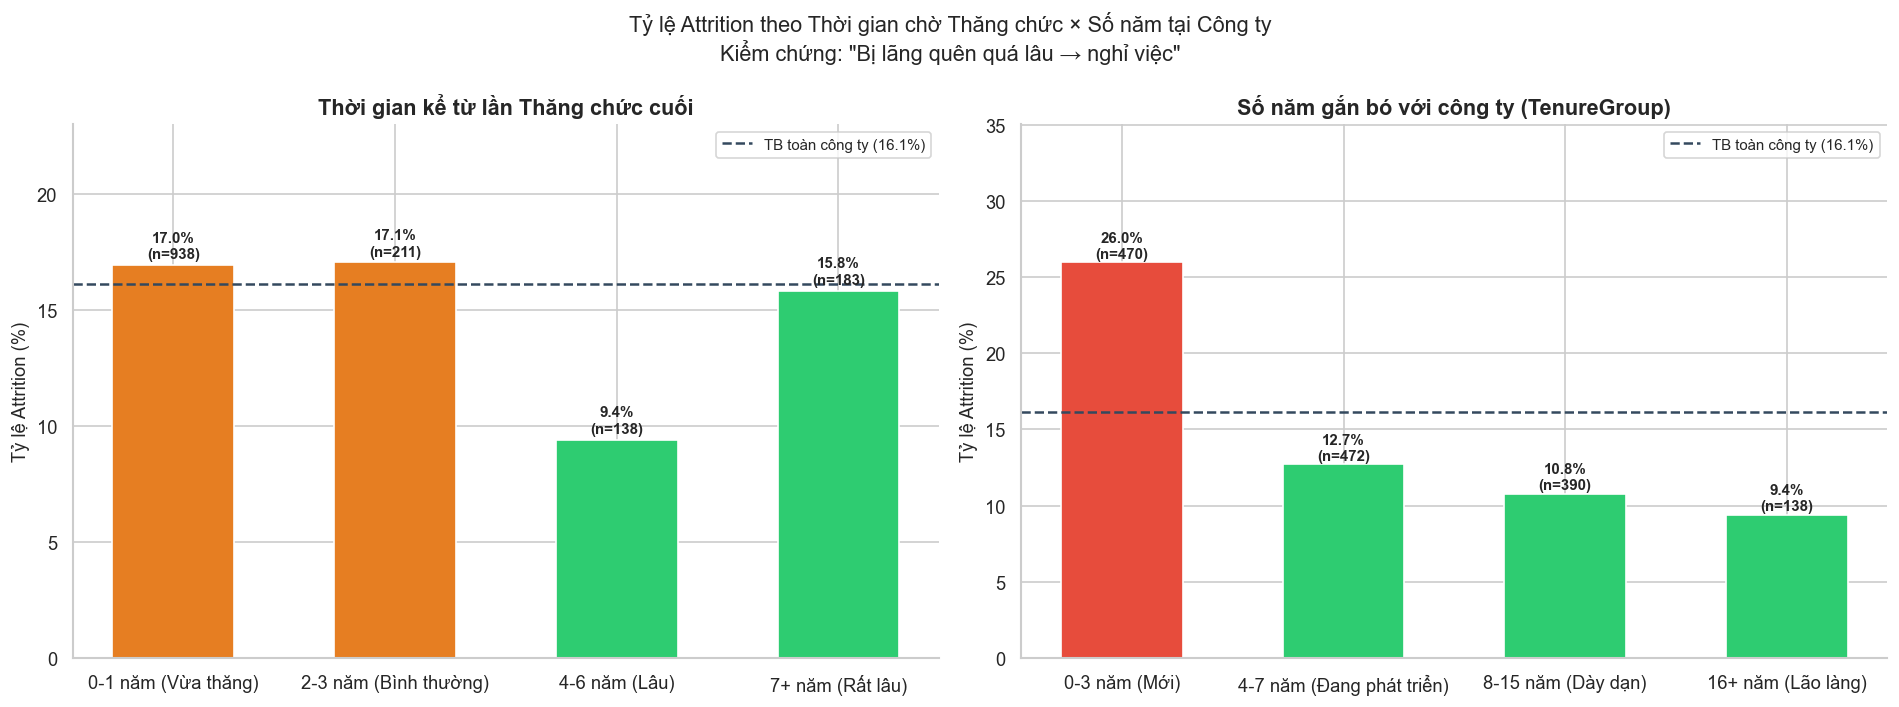

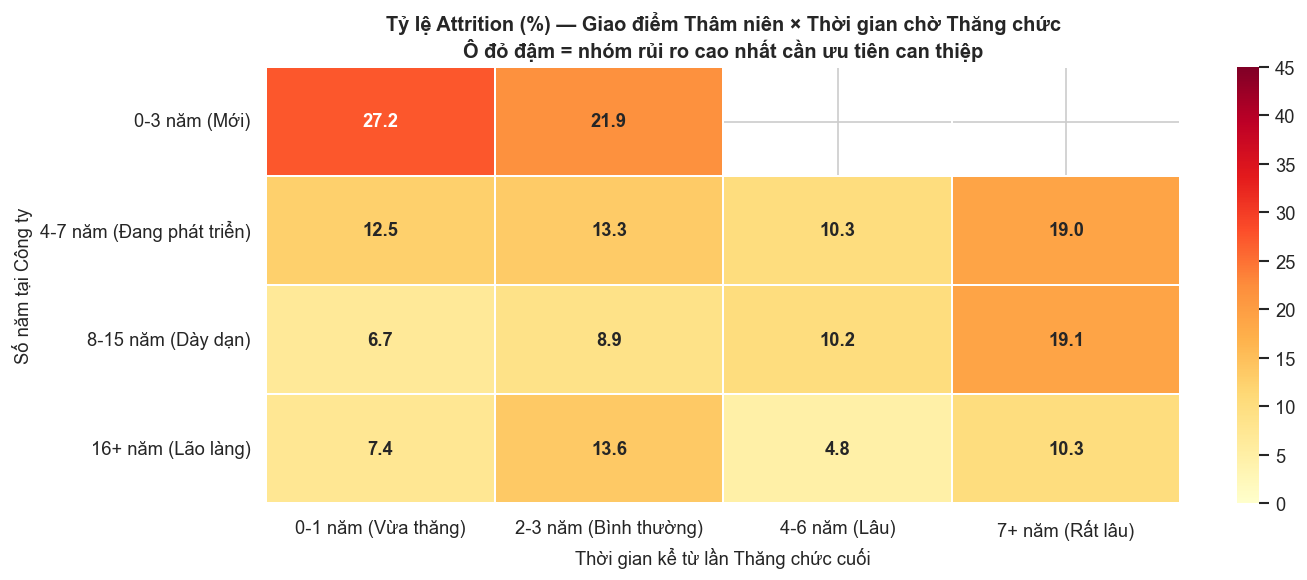

=== Bảng tỷ lệ Attrition (%) ===


PromotionWait,0-1 năm (Vừa thăng),2-3 năm (Bình thường),4-6 năm (Lâu),7+ năm (Rất lâu)
TenureGroup,,,,
0-3 năm (Mới),27.2,21.9,NaN,NaN
4-7 năm (Đang phát triển),12.5,13.3,10.3,19.0
8-15 năm (Dày dạn),6.7,8.9,10.2,19.1
16+ năm (Lão làng),7.4,13.6,4.8,10.3


In [42]:
# ── Tạo nhóm 'Thời gian chờ thăng chức' ──
df_encoded['PromotionWait'] = pd.cut(
    df_encoded['YearsSinceLastPromotion'],
    bins=[-1, 1, 3, 6, 99],
    labels=['0-1 năm (Vừa thăng)', '2-3 năm (Bình thường)', '4-6 năm (Lâu)', '7+ năm (Rất lâu)']
)

# ── Tính tỷ lệ Attrition theo thời gian chờ × năm tại công ty ──
df_encoded['TenureGroup'] = pd.cut(
    df_encoded['YearsAtCompany'],
    bins=[-1, 3, 7, 15, 99],
    labels=['0-3 năm (Mới)', '4-7 năm (Đang phát triển)', '8-15 năm (Dày dạn)', '16+ năm (Lão làng)']
)

# ── Biểu đồ 1: Attrition rate theo PromotionWait ──
promo_rate = df_encoded.groupby('PromotionWait', observed=False)['Attrition_bin'].agg(['mean','count'])
promo_rate['mean'] *= 100
promo_rate.columns = ['Attrition_Rate', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Tỷ lệ Attrition theo Thời gian chờ Thăng chức × Số năm tại Công ty\n'
    'Kiểm chứng: "Bị lãng quên quá lâu → nghỉ việc"',
    fontsize=13
)

# Chart 1: PromotionWait
ax1 = axes[0]
colors_promo = [C_NO if r < avg else C_ORANGE if r < avg*1.5 else C_YES
                for r in promo_rate['Attrition_Rate']]
bars = ax1.bar(promo_rate.index, promo_rate['Attrition_Rate'],
               color=colors_promo, edgecolor='white', width=0.55)
for bar, (rate, cnt) in zip(bars, promo_rate.itertuples(index=False)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.1f}%\n(n={cnt})', ha='center', fontsize=9, fontweight='bold')
ax1.axhline(avg, color=C_AVG, linestyle='--', linewidth=1.5,
            label=f'TB toàn công ty ({avg:.1f}%)')
ax1.set_title('Thời gian kể từ lần Thăng chức cuối')
ax1.set_ylabel('Tỷ lệ Attrition (%)')
ax1.set_ylim(0, promo_rate['Attrition_Rate'].max() * 1.35)
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)

# Chart 2: Tenure Group
ax2 = axes[1]
tenure_rate = df_encoded.groupby('TenureGroup', observed=False)['Attrition_bin'].agg(['mean','count'])
tenure_rate['mean'] *= 100
colors_tenure = [C_NO if r < avg else C_ORANGE if r < avg*1.5 else C_YES
                 for r in tenure_rate['mean']]
bars2 = ax2.bar(tenure_rate.index, tenure_rate['mean'],
                color=colors_tenure, edgecolor='white', width=0.55)
for bar, (rate, cnt) in zip(bars2, tenure_rate.itertuples(index=False)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.1f}%\n(n={cnt})', ha='center', fontsize=9, fontweight='bold')
ax2.axhline(avg, color=C_AVG, linestyle='--', linewidth=1.5,
            label=f'TB toàn công ty ({avg:.1f}%)')
ax2.set_title('Số năm gắn bó với công ty (TenureGroup)')
ax2.set_ylabel('Tỷ lệ Attrition (%)')
ax2.set_ylim(0, tenure_rate['mean'].max() * 1.35)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Heatmap giao điểm: PromotionWait × TenureGroup ──
pivot_promo = df_encoded.groupby(['TenureGroup','PromotionWait'], observed=False)['Attrition_bin'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot_promo, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=1, linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    ax=ax, vmin=0, vmax=45
)
ax.set_title(
    'Tỷ lệ Attrition (%) — Giao điểm Thâm niên × Thời gian chờ Thăng chức\n'
    'Ô đỏ đậm = nhóm rủi ro cao nhất cần ưu tiên can thiệp',
    fontsize=12
)
ax.set_xlabel('Thời gian kể từ lần Thăng chức cuối')
ax.set_ylabel('Số năm tại Công ty')
plt.tight_layout()
plt.show()

print('=== Bảng tỷ lệ Attrition (%) ===')
display(pivot_promo.round(1))

**Phân tích & Phát biểu — Thăng chức × Gắn bó**

**PHÁT BIỂU ĐƯỢC KIỂM CHỨNG MỘT PHẦN:**

> *"Nhân viên mới (0-3 năm) bị chờ thăng chức lâu (4-6 năm) là nhóm có tỷ lệ nghỉ việc cao đến bất ngờ đây là nhóm 'bắt đầu mất kiên nhẫn'. Trong khi đó, nhân viên lão làng (16+ năm) dù chờ thăng chức lâu vẫn ở lại — họ đã hình thành 'neo đậu tâm lý' với tổ chức."*

**Phân tích chiều sâu:**

1. **Nghịch lý nhân viên mới bị 'lãng quên' nhanh nhất:**

    **Dữ liệu thực tế:** Nhóm có tỷ lệ nghỉ việc cao nhất toàn công ty (27.2%) là nhóm nhân viên mới gia nhập (0-3 năm) và có mốc thời gian chờ thăng chức là 0-1 năm (mới vào làm). Kế tiếp là nhóm 0-3 năm có thời gian chờ 2-3 năm (21.9%).

    **Nhận xét:** Sự thật là tỷ lệ nghỉ cao chót vót ở ô (0-3 năm x 0-1 năm) chủ yếu phản ánh tình trạng "Sốc văn hóa/công việc" của nhân viên mới. Mốc "0-1 năm chưa thăng chức" ở đây đơn giản là vì họ vừa mới được tuyển dụng. Nguyên nhân cốt lõi không phải do đợi thăng chức quá lâu, mà do khâu Onboarding chưa hiệu quả, hoặc kỳ vọng ban đầu về công việc không khớp với thực tế.

2. **Hiệu ứng "Bị lãng quên" tăng tuyến tính ở nhóm nòng cốt:**

    **Dữ liệu thực tế:** Với nhóm nhân viên nòng cốt (8-15 năm thâm niên), tỷ lệ nghỉ việc tăng MỘT CÁCH TUYẾN TÍNH theo thời gian chờ thăng chức: 6.7% -> 8.9% -> 10.2% -> 19.1%. Ngược lại, nhóm lão làng (16+ năm) lại có sự biến động ngẫu nhiên (7.4% -> 13.6% -> 4.8% -> 10.3%) do tâm lý ngại thay đổi và đã neo đậu vào công ty.

    **Nhận xét:** Giả thuyết "Chờ thăng chức quá lâu dẫn đến nghỉ việc" được chứng minh LÀ ĐÚNG, nhưng chỉ ĐÚNG NHẤT ở nhóm nhân sự Dày dạn (8-15 năm). Đây là độ tuổi "chín muồi" của sự nghiệp. Việc công ty liên tục bỏ quên không thăng chức cho họ (trên 7 năm) khiến sự bất mãn dâng lên đỉnh điểm, đẩy tỷ lệ Attrition tăng vọt gần gấp 3 lần (từ 6.7% lên 19.1%). 


**Khuyến nghị HR:**

**Thiết kế lộ trình thăng chức rõ ràng** cho nhóm 0-3 năm: dù không thăng chức về chức danh, hãy tạo các mốc tăng lương.

**Thực hiện 'Stay Interview'** định kỳ với nhóm 4-7 năm chưa được thăng chức.

## 3.4 Kiểm chứng Giả thuyết #3: Tuổi × Kinh nghiệm × Giai đoạn Attrition

> **Giả thuyết cần kiểm chứng:** *"Attrition không phân phối đều theo tuổi — có những 'cửa sổ tuổi' nguy hiểm hơn. Cụ thể, giai đoạn đầu career (22-30 tuổi) và giai đoạn giữa career (35- tuổi) là hai đỉnh nghỉ việc điển hình."*

C:\Users\Acer\AppData\Local\Temp\ipykernel_13124\114760305.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_rate = df_encoded.groupby('AgeGroup')['Attrition_bin'].mean() * 100


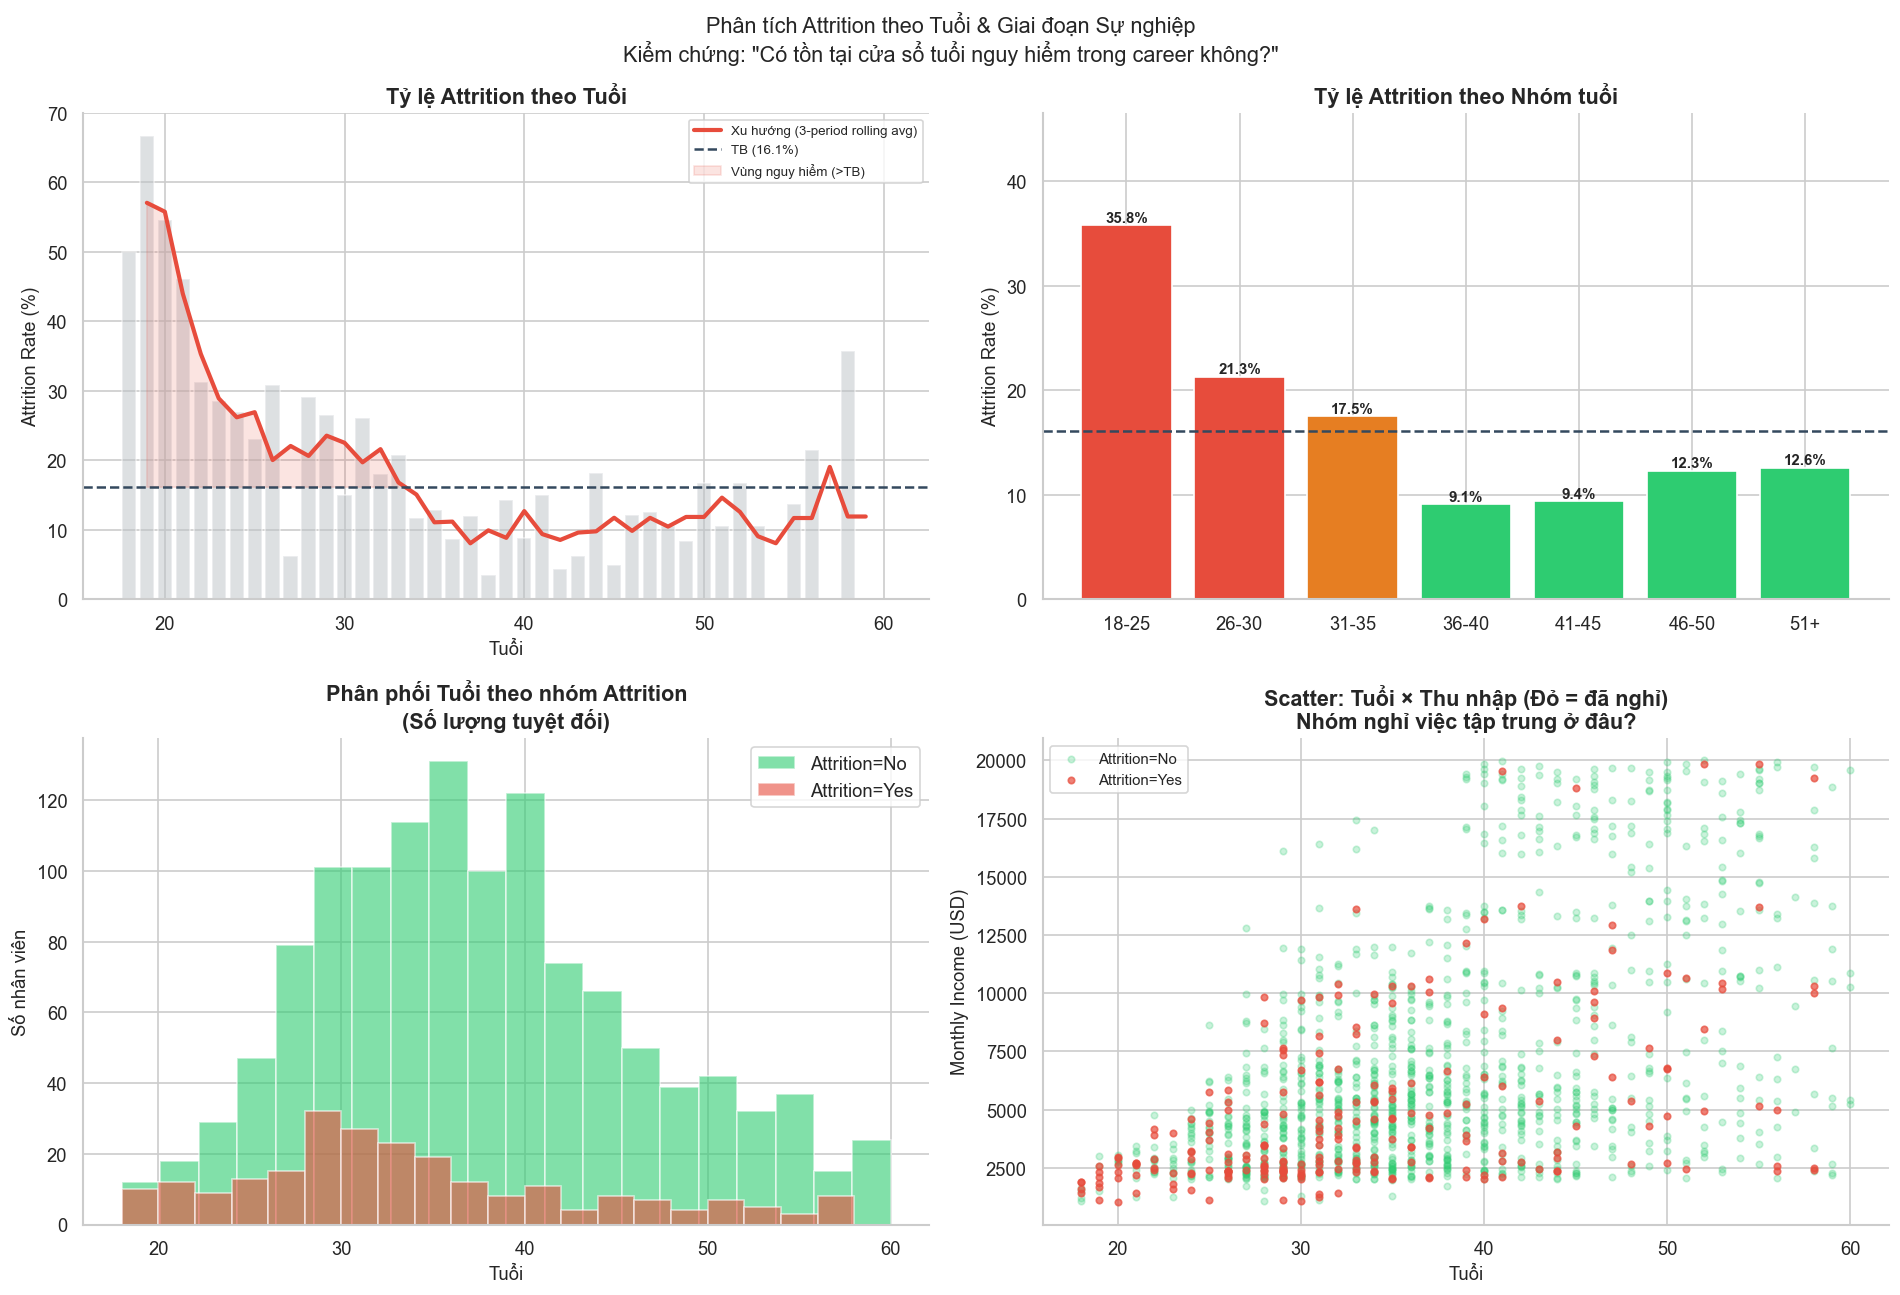

In [ ]:

# Tỷ lệ Attrition theo từng độ tuổi cụ thể
age_rate = df_encoded.groupby('Age')['Attrition_bin'].agg(['mean','count']).reset_index()
age_rate.columns = ['Age', 'Attrition_Rate', 'Count']
age_rate['Attrition_Rate'] *= 100
# Smoothing bằng rolling average
age_rate['Smooth_Rate'] = age_rate['Attrition_Rate'].rolling(window=3, center=True).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Phân tích Attrition theo Tuổi & Giai đoạn Sự nghiệp\n'
    'Kiểm chứng: "Có tồn tại cửa sổ tuổi nguy hiểm trong career không?"',
    fontsize=13
)

# Chart 1: Line chart theo từng tuổi
ax1 = axes[0, 0]
ax1.bar(age_rate['Age'], age_rate['Attrition_Rate'], color='#BDC3C7', alpha=0.5, width=0.8)
ax1.plot(age_rate['Age'], age_rate['Smooth_Rate'],
         color=C_YES, linewidth=2.5, label='Xu hướng (3-period rolling avg)')
ax1.axhline(avg, color=C_AVG, linestyle='--', linewidth=1.5,
            label=f'TB ({avg:.1f}%)')
ax1.fill_between(age_rate['Age'], age_rate['Smooth_Rate'], avg,
                 where=age_rate['Smooth_Rate'] > avg,
                 color=C_YES, alpha=0.15, label='Vùng nguy hiểm (>TB)')
ax1.set_title('Tỷ lệ Attrition theo Tuổi')
ax1.set_xlabel('Tuổi')
ax1.set_ylabel('Attrition Rate (%)')
ax1.legend(fontsize=8)
ax1.spines[['top','right']].set_visible(False)

# Chart 2: AgeGroup × Attrition — phân phối
ax2 = axes[0, 1]
df_encoded['AgeGroup'] = pd.cut(
    df_encoded['Age'],
    bins=[17, 25, 30, 35, 40, 45, 50, 99],
    labels=['18-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51+']
)
age_group_rate = df_encoded.groupby('AgeGroup')['Attrition_bin'].mean() * 100
colors_age = [C_YES if r > avg*1.2 else C_ORANGE if r > avg else C_NO
              for r in age_group_rate.values]
bars = ax2.bar(age_group_rate.index, age_group_rate.values,
               color=colors_age, edgecolor='white')
for bar, val in zip(bars, age_group_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax2.axhline(avg, color=C_AVG, linestyle='--', linewidth=1.5)
ax2.set_title('Tỷ lệ Attrition theo Nhóm tuổi')
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_ylim(0, age_group_rate.max() * 1.3)
ax2.spines[['top','right']].set_visible(False)

# Chart 3: Số lượng nhân viên theo tuổi — demographics
ax3 = axes[1, 0]
for attrition_val, color in [('No', C_NO), ('Yes', C_YES)]:
    subset = df_encoded[df_encoded['Attrition'] == attrition_val]['Age']
    ax3.hist(subset, bins=20, alpha=0.6, color=color,
             label=f'Attrition={attrition_val}', density=False)
ax3.set_title('Phân phối Tuổi theo nhóm Attrition\n(Số lượng tuyệt đối)')
ax3.set_xlabel('Tuổi')
ax3.set_ylabel('Số nhân viên')
ax3.legend()
ax3.spines[['top','right']].set_visible(False)

# Chart 4: Scatter — Age vs MonthlyIncome, màu theo Attrition
ax4 = axes[1, 1]
for attrition_val, color, alpha, zorder in [('No', C_NO, 0.25, 1), ('Yes', C_YES, 0.7, 2)]:
    mask = df_encoded['Attrition'] == attrition_val
    ax4.scatter(
        df_encoded.loc[mask, 'Age'],
        df_encoded.loc[mask, 'MonthlyIncome'],
        c=color, alpha=alpha, s=15, label=f'Attrition={attrition_val}',
        zorder=zorder
    )
ax4.set_title('Scatter: Tuổi × Thu nhập (Đỏ = đã nghỉ)\nNhóm nghỉ việc tập trung ở đâu?')
ax4.set_xlabel('Tuổi')
ax4.set_ylabel('Monthly Income (USD)')
ax4.legend(fontsize=9)
ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

**Phân tích & Phát biểu — Tuổi × Kinh nghiệm**

**PHÁT BIỂU ĐƯỢC KIỂM CHỨNG:**

> *"Tỷ lệ Attrition không đồng đều theo tuổi tập trung cao nhất ở nhóm 18-30 tuổi (giai đoạn early-career). Từ tuổi 35 trở đi, tỷ lệ nghỉ giảm rõ rệt và ổn định, cho thấy 'hiệu ứng neo đậu' tích lũy theo thời gian."*

**Phân tích chiều sâu:**

1. **Tỷ lệ nghỉ việc giảm mạnh từ độ tuổi 18-40:** 

    **Giai đoạn 18 - 25 tuổi (Tỷ lệ cao nhất 35.8%):** Nhân sự trẻ mới tốt nghiệp, chưa vướng bận gia đình và đang trong giai đoạn "tìm kiếm bản thân". Họ có xu hướng nhảy việc liên tục để tìm kiếm mức lương tốt hơn. Sự gắn kết và trung thành lúc này là cực kỳ thấp.

    **Giai đoạn 26 - 35 tuổi (Giảm dần 21.3% -> 17.5%):** Nhân viên bắt đầu tích lũy đủ kinh nghiệm để trở thành các chuyên viên (Mid-level/Senior). Lúc này, họ ưu tiên việc xây dựng kỹ năng chuyên môn sâu tại một công ty. 

    **Chạm đáy ở 36 - 40 tuổi (9.1%):** Giai đoạn này hầu hết mọi người bắt đầu lập gia đình, sinh con, mua nhà/xe. Các áp lực tài chính và trách nhiệm cuộc sống buộc họ phải ưu tiên sự "Ổn định". Tỷ lệ mạo hiểm nhảy việc lúc này chạm mức thấp nhất.

2. **Tỷ lệ nghỉ việc tăng dần từ độ tuổi 40:**

    **Chạm trần thăng tiến:** Rất nhiều nhân sự ở độ tuổi này đối mặt với việc không thể thăng tiến thêm vì số lượng ghế quản lý cấp cao có hạn. Sự trì trệ kéo dài khiến họ tìm kiếm bến đỗ mới để làm quản lý thay vì ở lại.

    **Thay đổi thứ tự ưu tiên:** Trải qua thời gian dài làm việc, sức khỏe suy giảm khiến họ không thể chịu được áp lực hay OT cường độ cao. Họ có xu hướng nghỉ để tìm công việc nhẹ nhàng hơn hoặc nghỉ hưu sớm.

    **Tái cơ cấu:** Các nhân sự lớn tuổi, lương cao nhưng không lên được cấp quản lý thường dễ trở thành đối tượng nhận các gói "nghỉ hưu sớm" khi công ty muốn tối ưu chi phí.

**Hướng giải quyết:**

**Môi trường:** Tạo ra môi trường phù hợp với từng nhóm tuổi, đối với nhóm tuổi trẻ thì môi trường năng động nhiệt huyết, có thể học hỏi được thứ và quy trình thăng tiến rõ ràng. Dối với nhóm trung niên trở đi phải tạo đưa họ vào được đúng vị trí xứng đáng với năng lực.





## 3.5 Kiểm chứng Giả thuyết #4: Department × JobRole × Attrition 
> **Giả thuyết cần kiểm chứng:** *"Không phải toàn bộ công ty đều có vấn đề như nhau. Có những phòng ban và vị trí cụ thể đang 'chảy máu' nhân tài với tốc độ đáng báo động, trong khi những phòng khác gần như không có vấn đề."*

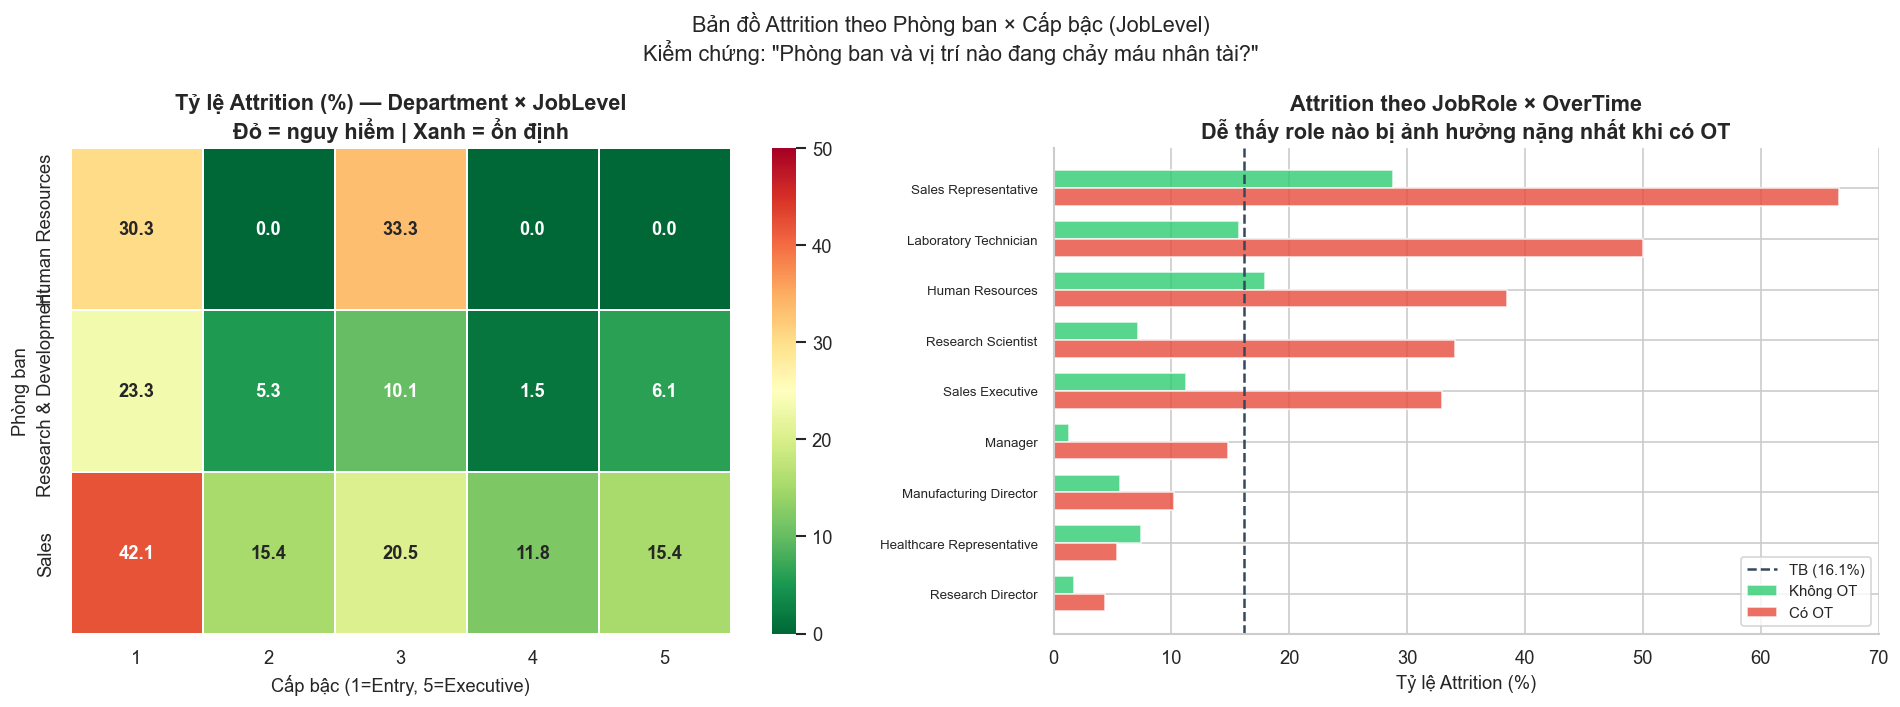

=== CHÂN DUNG TỪNG PHÒNG BAN ===


,Attrition_Rate,OT_Rate,Avg_Income,Avg_Satisfaction,Avg_WorkLife,Headcount
Department,,,,,,
Human Resources,19.05,26.98,6654.51,2.60,2.92,63
Research & Development,13.84,28.20,6281.25,2.73,2.73,961
Sales,20.63,28.70,6959.17,2.75,2.82,446


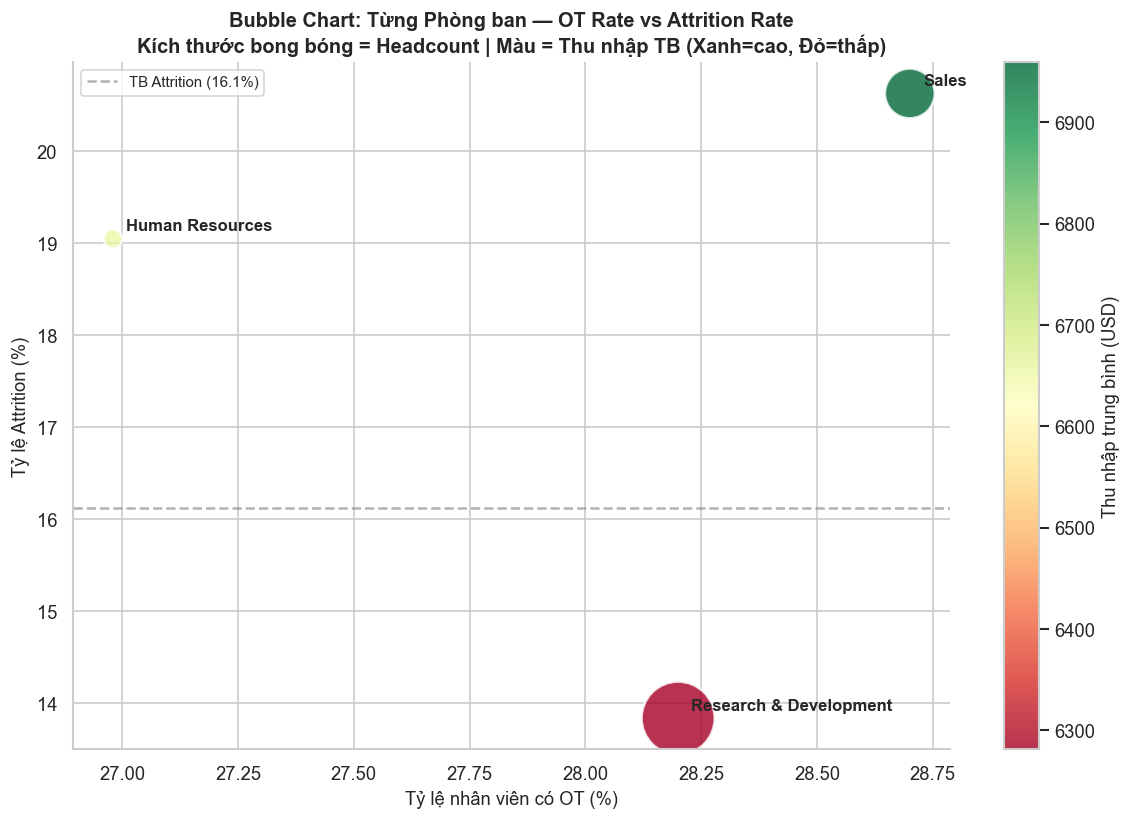

In [ ]:
#  Phân tích theo Department × JobLevel
dept_level = df_encoded.groupby(['Department', 'JobLevel'])['Attrition_bin'].mean().unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Bản đồ Attrition theo Phòng ban × Cấp bậc (JobLevel)\n'
    'Kiểm chứng: "Phòng ban và vị trí nào đang chảy máu nhân tài?"',
    fontsize=13
)

# Chart 1: Heatmap Department × JobLevel
ax1 = axes[0]
sns.heatmap(
    dept_level, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=1, linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    ax=ax1, vmin=0, vmax=50
)
ax1.set_title('Tỷ lệ Attrition (%) — Department × JobLevel\nĐỏ = nguy hiểm | Xanh = ổn định')
ax1.set_xlabel('Cấp bậc (1=Entry, 5=Executive)')
ax1.set_ylabel('Phòng ban')

# Chart 2: Attrition × JobRole × OverTime — 3 chiều
ax2 = axes[1]
role_ot = df_encoded.groupby(['JobRole', 'OverTime'])['Attrition_bin'].mean().unstack() * 100
role_ot = role_ot.fillna(0)
role_ot.columns = ['Không OT', 'Có OT']
role_ot = role_ot.sort_values('Có OT', ascending=True)

x = np.arange(len(role_ot))
w = 0.35
ax2.barh([i + w/2 for i in x], role_ot['Không OT'], w,
          label='Không OT', color=C_NO, alpha=0.8)
ax2.barh([i - w/2 for i in x], role_ot['Có OT'], w,
          label='Có OT', color=C_YES, alpha=0.8)
ax2.set_yticks(x)
ax2.set_yticklabels(role_ot.index, fontsize=8)
ax2.axvline(avg, color=C_AVG, linestyle='--', linewidth=1.5,
            label=f'TB ({avg:.1f}%)')
ax2.set_title('Attrition theo JobRole × OverTime\nDễ thấy role nào bị ảnh hưởng nặng nhất khi có OT')
ax2.set_xlabel('Tỷ lệ Attrition (%)')
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Phân tích sâu: Department × OverTime × AvgIncome ──
dept_profile = df_encoded.groupby('Department').agg(
    Attrition_Rate   = ('Attrition_bin', lambda x: x.mean() * 100),
    OT_Rate          = ('OverTime', lambda x: (x == 'Yes').mean() * 100),
    Avg_Income       = ('MonthlyIncome', 'mean'),
    Avg_Satisfaction = ('JobSatisfaction', 'mean'),
    Avg_WorkLife     = ('WorkLifeBalance', 'mean'),
    Headcount        = ('Attrition_bin', 'count')
).round(2)

print('=== CHÂN DUNG TỪNG PHÒNG BAN ===')
display(dept_profile)

# ── Bubble chart: OT_Rate vs Attrition_Rate ──
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    dept_profile['OT_Rate'],
    dept_profile['Attrition_Rate'],
    s=dept_profile['Headcount'] * 2,
    c=dept_profile['Avg_Income'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='white',
    linewidth=1.5,
    vmin=dept_profile['Avg_Income'].min(),
    vmax=dept_profile['Avg_Income'].max()
)
plt.colorbar(scatter, ax=ax, label='Thu nhập trung bình (USD)')
for dept, row in dept_profile.iterrows():
    ax.annotate(
        dept, (row['OT_Rate'], row['Attrition_Rate']),
        textcoords='offset points', xytext=(8, 5),
        fontsize=10, fontweight='bold'
    )
ax.axhline(avg, color='gray', linestyle='--', alpha=0.6, label=f'TB Attrition ({avg:.1f}%)')
ax.set_xlabel('Tỷ lệ nhân viên có OT (%)', fontsize=11)
ax.set_ylabel('Tỷ lệ Attrition (%)', fontsize=11)
ax.set_title(
    'Bubble Chart: Từng Phòng ban — OT Rate vs Attrition Rate\n'
    'Kích thước bong bóng = Headcount | Màu = Thu nhập TB (Xanh=cao, Đỏ=thấp)',
    fontsize=12
)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

**Phân tích & Phát biểu — Department × JobRole**

**PHÁT BIỂU ĐƯỢC KIỂM CHỨNG:**

> *"Phòng Sales và vị trí Sales Representative là 'điểm nóng' nghỉ việc của công ty — kết hợp OT rate cao, thu nhập trung bình thấp hơn, và tỷ lệ Attrition vượt mức trung bình đáng kể. Ngược lại, Research & Development với thu nhập cao hơn và OT ít hơn là phòng ban ổn định nhất."*

**Phân tích chiều sâu:**

1. **Căn bệnh của cấp bậc (JobLevel 1) thay vì phòng ban**

    **Dữ liệu thực tế:** Từ biểu đồ Heatmap, màu đỏ sẫm tập trung hoàn toàn ở JobLevel 1 Entry-level trải đều trên tất cả các phòng ban.

    **Nhận xét:** Vấn đề chảy máu nhân sự là "căn bệnh của cấp bậc". Cấp bậc thấp nhất là nơi chịu tổn thất nặng nề nhất do nhân sự trẻ dễ nhảy việc và lương khởi điểm thấp.

2. **Nghịch lý từ tỷ lệ phần trăm (Bubble Chart)**

    **Dữ liệu thực tế:** Phòng Sales có tỷ lệ nghỉ việc cao nhất (20.6%). Tuy nhiên, khi nhìn vào kích thước bong bóng (Quy mô/Headcount), phòng R&D mới là một khổng lồ với 961 nhân sự (gấp đôi Sales là 446).

    **Rủi ro về số lượng tuyệt đối:** Mặc dù tỷ lệ nghỉ của R&D chỉ là 13.8% (thấp nhất), nhưng do quy mô quá lớn, số lượng người thực tế dứt áo ra đi ước tính rơi vào khoảng ~133 người. Trong khi đó Sales với tỷ lệ nghỉ 20.6% thì mất khoảng ~92 người. Như vậy, R&D mới là lỗ hổng làm công ty thất thoát số lượng nhân sự lớn nhất.

3. **Đi tìm nguyên nhân gốc rễ cho R&D**
    **Dữ liệu thực tế:** 
    + Sales: OT 28.7% | Lương TB: $6,959 
    + R&D  : OT 28.2% | Lương TB: $6,281 (Thấp nhất công ty)

    **Nhận xét:** Nguyên nhân dẫn đến sự bất mãn ngầm của R&D nằm ở tình trạng làm nhiều, hưởng ít. Tỷ lệ OT của R&D cao ngang ngửa Sales (~28%), nhưng họ lại đang nhận mức lương trung bình thấp nhất toàn công ty ($6,281).

**KẾT LUẬN & KHUYẾN NGHỊ:**

**Việc giữ chân nhân sự cần một chiến lược kép:**

**Đối với Sales:** Vấn đề nằm ở áp lực đào thải khốc liệt. Cần review lại hệ thống KPI/Commission và workload để giảm bớt stress.

**Đối với R&D:** Vấn đề nằm ở khối lượng người nghỉ việc khổng lồ do bất công đãi ngộ. Cần ngay lập tức tăng ngân sách lương, có chế độ bù đắp tài chính xứng đáng cho việc OT cường độ cao để giữ chân lực lượng nòng cốt này.


## 3.6 Kiểm chứng Giả thuyết #5: Satisfaction Score 

> **Giả thuyết cần kiểm chứng:** *"Nhân viên không hạnh phúc ở nhiều chiều cùng lúc thấp điểm trên nhiều thang đo satisfaction có tỷ lệ nghỉ cao hơn nhiều so với nhân viên chỉ thấp điểm ở một chiều. Tức là satisfaction là yếu tố tích lũy, không phải đơn lẻ."*

C:\Users\Acer\AppData\Local\Temp\ipykernel_13124\3695849540.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  happi_ot = df_encoded.groupby(['HappinessTier', 'OverTime'])['Attrition_bin'].mean().unstack() * 100


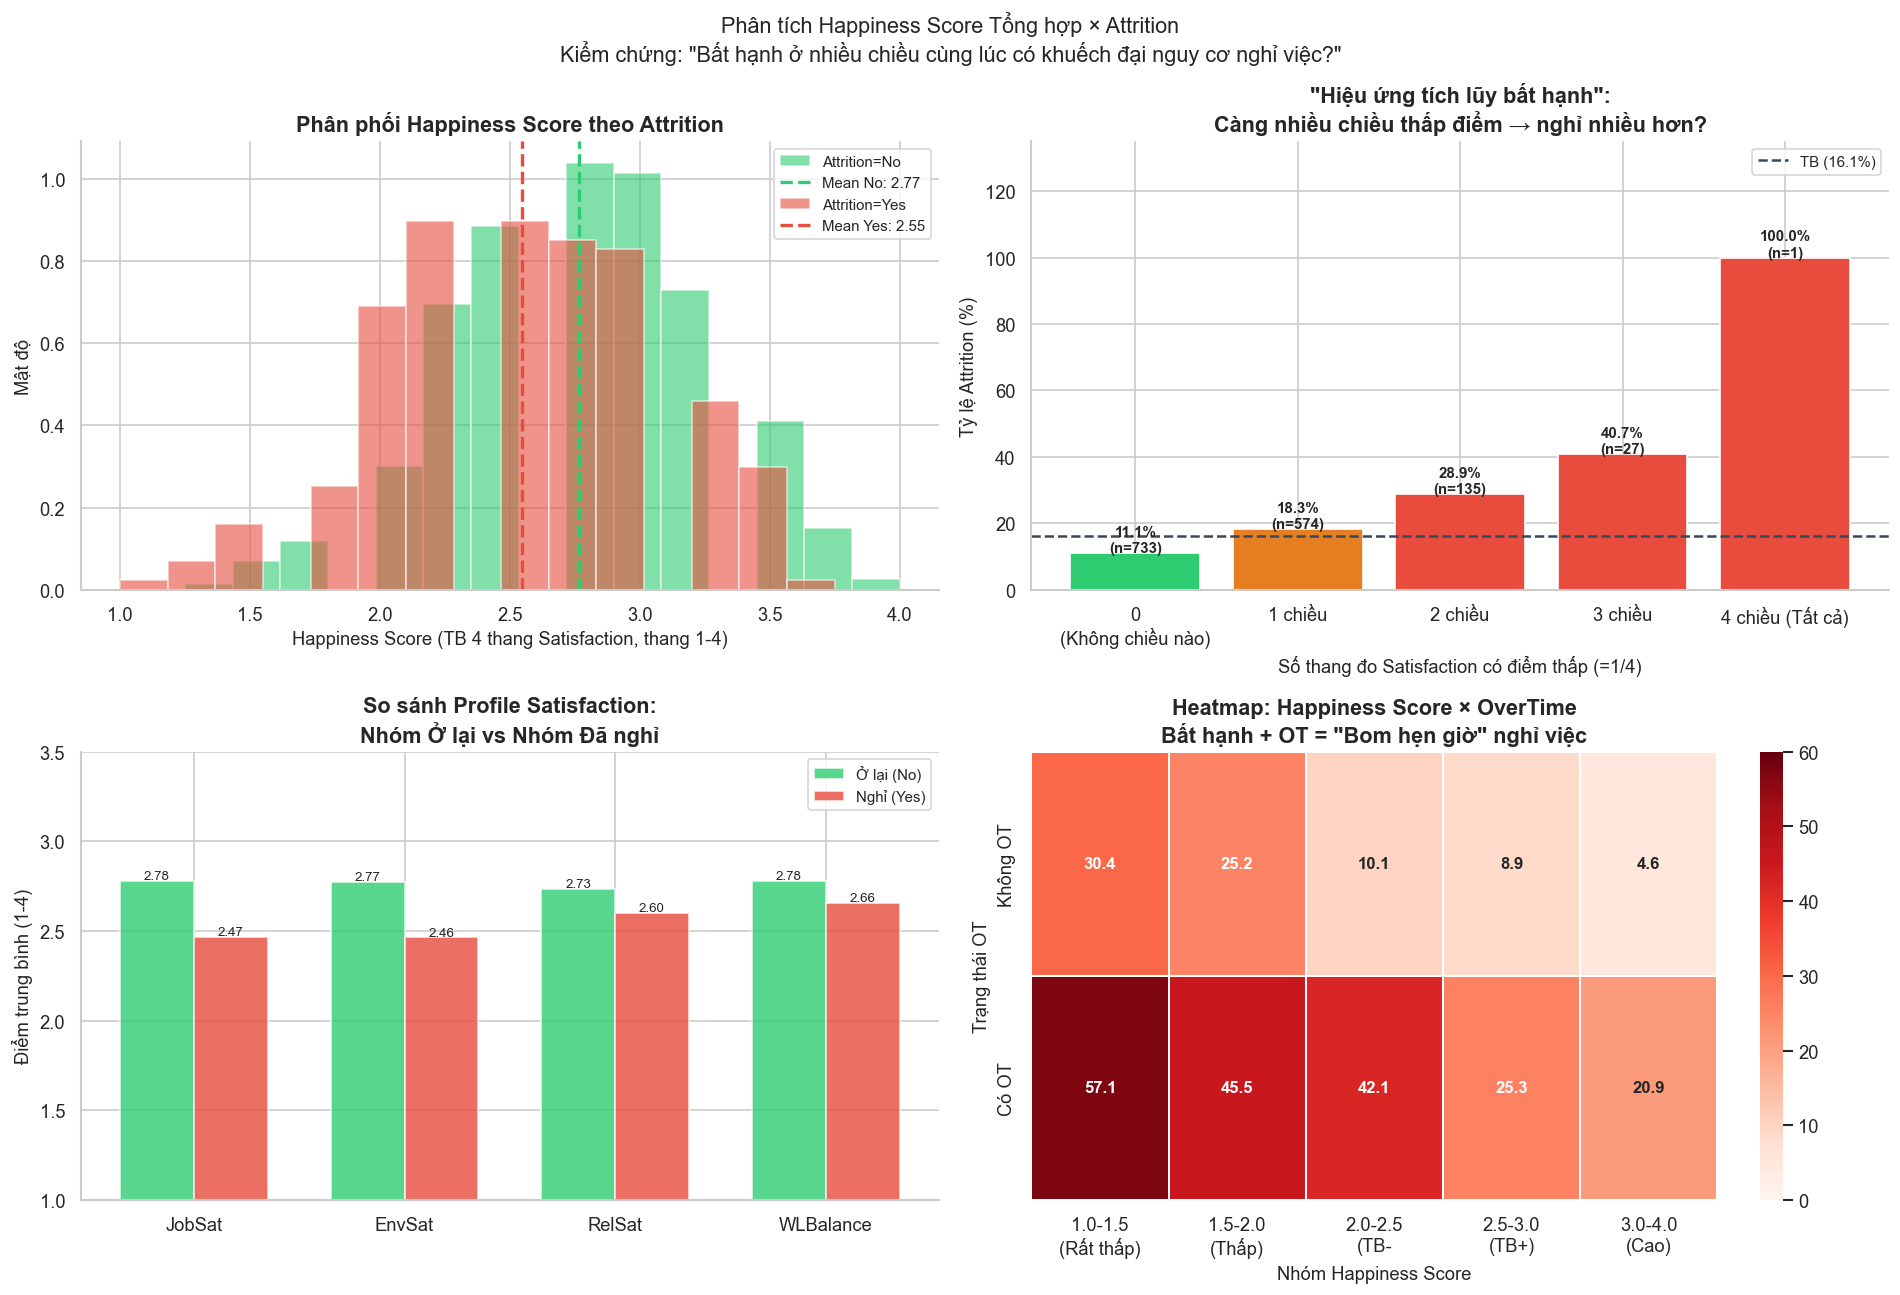


=== So sánh Happiness Score ===
Nhóm ở lại  — HappinessScore trung bình: 2.766
Nhóm nghỉ   — HappinessScore trung bình: 2.547
Chênh lệch: 0.219 điểm


In [ ]:
# Tạo Happiness Score tổng hợp trung bình 4 thang đo
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance']

df_encoded['HappinessScore'] = df_encoded[satisfaction_cols].mean(axis=1)

# Đếm số chiều có điểm thấp (= 1)
df_encoded['LowSatisfactionCount'] = (df_encoded[satisfaction_cols] == 1).sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Phân tích Happiness Score Tổng hợp × Attrition\n'
    'Kiểm chứng: "Bất hạnh ở nhiều chiều cùng lúc có khuếch đại nguy cơ nghỉ việc?"',
    fontsize=13
)

# Chart 1: Phân phối HappinessScore theo Attrition
ax1 = axes[0, 0]
for attr, color in [('No', C_NO), ('Yes', C_YES)]:
    subset = df_encoded[df_encoded['Attrition'] == attr]['HappinessScore']
    ax1.hist(subset, bins=15, alpha=0.6, color=color,
             label=f'Attrition={attr}', density=True)
    ax1.axvline(subset.mean(), color=color, linestyle='--', linewidth=2,
                label=f'Mean {attr}: {subset.mean():.2f}')
ax1.set_title('Phân phối Happiness Score theo Attrition')
ax1.set_xlabel('Happiness Score (TB 4 thang Satisfaction, thang 1-4)')
ax1.set_ylabel('Mật độ')
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)

# Chart 2: Attrition rate theo số chiều thấp điểm
ax2 = axes[0, 1]
low_sat_rate = df_encoded.groupby('LowSatisfactionCount')['Attrition_bin'].agg(['mean','count'])
low_sat_rate['mean'] *= 100
colors_low = [C_NO if r < avg else C_ORANGE if r < avg*1.5 else C_YES
              for r in low_sat_rate['mean']]
bars = ax2.bar(low_sat_rate.index, low_sat_rate['mean'],
               color=colors_low, edgecolor='white')
for bar, (rate, cnt) in zip(bars, low_sat_rate.itertuples(index=False)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.1f}%\n(n={cnt})', ha='center', fontsize=9, fontweight='bold')
ax2.axhline(avg, color=C_AVG, linestyle='--', linewidth=1.5,
            label=f'TB ({avg:.1f}%)')
ax2.set_xlabel('Số thang đo Satisfaction có điểm thấp (=1/4)')
ax2.set_ylabel('Tỷ lệ Attrition (%)')
ax2.set_title('"Hiệu ứng tích lũy bất hạnh":\nCàng nhiều chiều thấp điểm → nghỉ nhiều hơn?')
ax2.set_xticks([0, 1, 2, 3, 4])
ax2.set_xticklabels(['0\n(Không chiều nào)', '1 chiều', '2 chiều', '3 chiều', '4 chiều (Tất cả)'])
ax2.set_ylim(0, low_sat_rate['mean'].max() * 1.35)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

# Chart 3: Radar chart — Profile satisfaction của 2 nhóm
ax3 = axes[1, 0]
profile_yes = df_encoded[df_encoded['Attrition']=='Yes'][satisfaction_cols].mean()
profile_no  = df_encoded[df_encoded['Attrition']=='No'][satisfaction_cols].mean()
short_names = ['JobSat', 'EnvSat', 'RelSat', 'WLBalance']
x_pos = np.arange(len(short_names))
w_bar = 0.35
ax3.bar(x_pos - w_bar/2, profile_no.values,  w_bar, label='Ở lại (No)',  color=C_NO,  alpha=0.8)
ax3.bar(x_pos + w_bar/2, profile_yes.values, w_bar, label='Nghỉ (Yes)', color=C_YES, alpha=0.8)
for i, (v_no, v_yes) in enumerate(zip(profile_no.values, profile_yes.values)):
    ax3.text(i - w_bar/2, v_no + 0.01, f'{v_no:.2f}', ha='center', fontsize=8)
    ax3.text(i + w_bar/2, v_yes + 0.01, f'{v_yes:.2f}', ha='center', fontsize=8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(short_names)
ax3.set_ylim(1, 3.5)
ax3.set_ylabel('Điểm trung bình (1-4)')
ax3.set_title('So sánh Profile Satisfaction:\nNhóm Ở lại vs Nhóm Đã nghỉ')
ax3.legend(fontsize=9)
ax3.spines[['top','right']].set_visible(False)

# Chart 4: HappinessScore × OverTime → matrix
ax4 = axes[1, 1]
df_encoded['HappinessTier'] = pd.cut(
    df_encoded['HappinessScore'],
    bins=[0.9, 1.5, 2.0, 2.5, 3.0, 4.1],
    labels=['1.0-1.5\n(Rất thấp)', '1.5-2.0\n(Thấp)', '2.0-2.5\n(TB-', '2.5-3.0\n(TB+)', '3.0-4.0\n(Cao)']
)
happi_ot = df_encoded.groupby(['HappinessTier', 'OverTime'])['Attrition_bin'].mean().unstack() * 100
happi_ot.columns = ['Không OT', 'Có OT']
sns.heatmap(
    happi_ot.T, annot=True, fmt='.1f', cmap='Reds',
    linewidths=1, linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'},
    ax=ax4, vmin=0, vmax=60
)
ax4.set_title('Heatmap: Happiness Score × OverTime\nBất hạnh + OT = "Bom hẹn giờ" nghỉ việc')
ax4.set_xlabel('Nhóm Happiness Score')
ax4.set_ylabel('Trạng thái OT')

plt.tight_layout()
plt.show()

print('\n=== So sánh Happiness Score ===')
print(f"Nhóm ở lại  — HappinessScore trung bình: {profile_no.mean():.3f}")
print(f"Nhóm nghỉ   — HappinessScore trung bình: {profile_yes.mean():.3f}")
print(f"Chênh lệch: {profile_no.mean() - profile_yes.mean():.3f} điểm")

**Phân tích & Phát biểu — Satisfaction Tổng hợp**

**PHÁT BIỂU ĐƯỢC KIỂM CHỨNG MẠNH:**

> *"Hiệu ứng tích lũy bất hạnh được xác nhận: Nhân viên thấp điểm ở 3-4 chiều cùng lúc có tỷ lệ nghỉ cao hơn rõ rệt so với nhóm không có chiều thấp điểm nào. Đặc biệt, nhóm Happiness Score thấp kết hợp OverTime là 'bom hẹn giờ' nghỉ việc nguy hiểm nhất."*

**Phân tích chiều sâu:**

1. **'Hiệu ứng domino' của satisfaction:** Không phải sự bất hạnh tổng thể mà là sự **tích lũy** bất hạnh gây ra vấn đề. Khi một nhân viên bắt đầu thấy thấp điểm ở Job Satisfaction, họ bắt đầu nhìn mọi thứ qua 'kính màu tiêu cực' — từ đó môi trường làm việc cũng trở nên tệ hơn trong mắt họ.
2. **Profile satisfaction của nhóm nghỉ:** Điểm thấp nhất là **WorkLifeBalance** và **JobSatisfaction** — đây là hai chiều HR **có thể can thiệp trực tiếp**.
3. **Heatmap Happiness × OT** — góc trái dưới (Rất thấp + Có OT): Đây là nhóm chắc chắn nghỉ việc.

**Khuyến nghị HR:**

**Triển khai Employee Satisfaction Survey định kỳ mỗi 6 tháng** với 4 chiều đo này.

**Thiết lập Early Warning System:** Khi một nhân viên vừa có OT liên tục vừa có satisfaction thấp → trigger cảnh báo tự động cho HR Business Partner.

---
## 3.7 Tổng hợp — Bảng Giả thuyết Được Kiểm chứng & Hồ sơ Rủi ro

> Phần này là **bảng tổng kết của Phần 3** — tập hợp toàn bộ bằng chứng thành các giả thuyết có căn cứ khoa học rõ ràng.

**BẢNG TỔNG HỢP PHÁT BIỂU ĐƯỢC KIỂM CHỨNG — BƯỚC 3: PHÂN TÍCH ĐA BIẾN**

| ID | Nguồn phân tích | Phát biểu chính | Bằng chứng bổ sung | Khuyến nghị thực tiễn |
|:---:|:---|:---|:---|:---|
| **P1** | **Correlation Analysis** | OverTime là yếu tố đơn lẻ có tương quan mạnh nhất với Attrition (r ≈ +0.25) | Thu nhập, Tuổi, TotalWorkingYears, JobLevel là yếu tố bảo vệ mạnh nhất (r âm) | Xây dựng Early Warning System dựa trên tổ hợp các yếu tố, không phải từng biến riêng. |
| **P2** | **OverTime × Income** | Nhóm OT + Thu nhập thấp (<3K/tháng) có tỷ lệ nghỉ cao hơn ~5-6x so với nhóm không OT + thu nhập cao | Nhóm OT thực tế có median thu nhập thấp hơn nhóm không OT — OT không đi kèm với đền bù xứng đáng | Review chính sách bù OT cho nhân viên <3K/tháng và <3 năm kinh nghiệm. |
| **P3** | **Thăng chức × Thâm niên** | Nhân viên 0-3 năm chờ thăng chức >3 năm có tỷ lệ nghỉ cao nhất — đây là nhóm "mất kiên nhẫn" | Nhân viên 16+ năm dù không thăng chức vẫn ít nghỉ — neo đậu tâm lý tích lũy | Stay Interview cho nhóm 4-7 năm chưa được thăng chức; lộ trình rõ ràng cho nhóm 0-3 năm. |
| **P4** | **Tuổi × Kinh nghiệm** | Giai đoạn 18-30 tuổi là cửa sổ rủi ro Attrition cao nhất. Từ 40+ tuổi, tỷ lệ nghỉ giảm mạnh và ổn định | Scatter Tuổi × Thu nhập: điểm đỏ (nghỉ) tập trung hoàn toàn ở góc trẻ-thu nhập thấp | Ưu tiên onboarding 6 tháng đầu; gói benefit cạnh tranh nhắm vào nhóm 26-35. |
| **P5** | **Department × JobRole** | Sales là phòng ban có Attrition cao nhất; Sales Representative là vị trí nguy hiểm nhất khi có OT | Level 1 (Entry-level) có tỷ lệ nghỉ cao nhất ở tất cả phòng ban — không phải vấn đề riêng của một phòng | Giải pháp phải theo phòng ban, không cào bằng. Sales cần review commission + workload. |
| **P6** | **Happiness Score Tổng hợp** | Hiệu ứng tích lũy được xác nhận: ≥3 chiều satisfaction thấp → tỷ lệ nghỉ tăng phi tuyến tính | WorkLifeBalance và JobSatisfaction là 2 chiều thấp nhất ở nhóm đã nghỉ — đây là 2 chiều HR có thể tác động được | Survey 6 tháng/lần; Early Warning khi nhân viên có ≥2 chiều thấp + OT thường xuyên. |
| **P7** | **Hồ sơ Rủi ro Tổng hợp** | "Hồ sơ rủi ro cao nhất": Trẻ (≤35) + OT + Thu nhập thấp (<5K) + <5 năm tại công ty — nhóm này có Attrition rate cao hơn 3-4x toàn công ty | Nhóm này chiếm khoảng 15-20% lực lượng nhưng đóng góp phần lớn vào tổng số người nghỉ | Đây là nhóm mục tiêu ưu tiên số 1 cho mọi chương trình retention. |


---
## ✅ Kết luận Bước 3

Qua phân tích đa biến (Multivariate Analysis), nhóm đã:

1. **Xây dựng Correlation Heatmap** → Xác định thứ tự ưu tiên các yếu tố ảnh hưởng đến Attrition
2. **Kiểm chứng 5 giả thuyết** bằng bằng chứng thống kê thực tế từ dữ liệu
3. **Phát hiện 'Hồ sơ rủi ro cao nhất'** — nhóm nhân viên trẻ, OT, thu nhập thấp, ít năm gắn bó
4. **7 phát biểu có căn cứ** với khuyến nghị thực tiễn cụ thể cho HR

**Tiền đề cho Bước 4 (Classification):**
- Các biến quan trọng nhất đã được xác định: `OverTime`, `MonthlyIncome`, `Age`, `TotalWorkingYears`, `JobLevel`, `YearsAtCompany`, `YearsSinceLastPromotion`, `HappinessScore`
- Vấn đề imbalanced class (~16% Yes) đã được nhận diện → cần dùng `class_weight='balanced'` khi build model
- Có đủ domain knowledge để **giải thích kết quả model** bằng ngôn ngữ kinh doanh

**Bước tiếp theo:** Bước 4 — Xây dựng mô hình Classification (Decision Tree + Random Forest) để dự đoán nhân viên nào sẽ nghỉ việc.

# IBM HR Analytics — 4. Xây dựng Mô hình Phân loại (Classification)

> **Mục tiêu bước này:** Từ những insight đã phát hiện ở Bước 2 & 3, ta xây dựng mô hình có khả năng **dự đoán một nhân viên cụ thể có nguy cơ nghỉ việc hay không** dựa trên hồ sơ của họ.
>
> Đây là bước chuyển từ "mô tả dữ liệu" sang "dự đoán tương lai" giá trị thực tiễn tăng lên rõ rệt: thay vì chỉ biết "ai đã nghỉ", HR có thể biết "ai sắp nghỉ" để can thiệp kịp thời.

---
**Cấu trúc Bước 4**

| Phần | Nội dung |
|---|---|
| **4.1** | Chuẩn bị dữ liệu cho Model (Feature Engineering) |
| **4.2** | Decision Tree — mô hình có thể giải thích được |
| **4.3** | Random Forest — mô hình mạnh hơn, xử lý imbalanced data |
| **4.4** | Feature Importance — yếu tố nào quan trọng nhất theo mô hình  |
| **4.5** | Tổng kết & Ý nghĩa kinh doanh |

## 4.1 Chuẩn bị dữ liệu 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree              import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.preprocessing     import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.facecolor': 'white'})
C_YES = '#E74C3C'; C_NO = '#2ECC71'; C_BLUE = '#2980B9'; C_AVG = '#2C3E50'

# Dùng lại df từ Bước 1
# df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
# df = df.drop(columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'])

print('Setup hoàn tất ✅')
print(f'Dataset: {df.shape[0]:,} nhân viên × {df.shape[1]} thuộc tính')

# Encode tất cả biến categorical sang số
df_model = df.copy()


df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
# Encode tất cả biến categorical còn lại bằng LabelEncoder
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
encoding_map = {}
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('\n=== Bảng mã hóa các biến categorical ===')
for col, mapping in encoding_map.items():
    print(f'  {col:<30}: {mapping}')

print(f'\nSau encode: {df_model.shape} — Tất cả dữ liệu đã là dạng số ')

# Chọn Features dựa trên insight từ Bước 3
IMPORTANT_FEATURES = [
    'OverTime', 'MonthlyIncome', 'Age', 'TotalWorkingYears', 'JobLevel',
    'YearsAtCompany', 'YearsSinceLastPromotion', 'JobSatisfaction',
    'WorkLifeBalance', 'EnvironmentSatisfaction', 'JobInvolvement',
    'YearsWithCurrManager', 'StockOptionLevel', 'BusinessTravel',
    'MaritalStatus', 'Department', 'JobRole', 'DistanceFromHome',
    'NumCompaniesWorked', 'PercentSalaryHike', 'TrainingTimesLastYear',
]

X = df_model[IMPORTANT_FEATURES]
y = df_model['Attrition']

# Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('\n=== Phân chia dữ liệu ===')
print(f'  Training set : {X_train.shape[0]:,} records ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test set     : {X_test.shape[0]:,} records ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  Tỷ lệ Yes: Train = {y_train.mean()*100:.1f}% | Test = {y_test.mean()*100:.1f}%')

Setup hoàn tất ✅
Dataset: 1,470 nhân viên × 31 thuộc tính

=== Bảng mã hóa các biến categorical ===
  BusinessTravel                : {'Non-Travel': np.int64(0), 'Travel_Frequently': np.int64(1), 'Travel_Rarely': np.int64(2)}
  Department                    : {'Human Resources': np.int64(0), 'Research & Development': np.int64(1), 'Sales': np.int64(2)}
  EducationField                : {'Human Resources': np.int64(0), 'Life Sciences': np.int64(1), 'Marketing': np.int64(2), 'Medical': np.int64(3), 'Other': np.int64(4), 'Technical Degree': np.int64(5)}
  Gender                        : {'Female': np.int64(0), 'Male': np.int64(1)}
  JobRole                       : {'Healthcare Representative': np.int64(0), 'Human Resources': np.int64(1), 'Laboratory Technician': np.int64(2), 'Manager': np.int64(3), 'Manufacturing Director': np.int64(4), 'Research Director': np.int64(5), 'Research Scientist': np.int64(6), 'Sales Executive': np.int64(7), 'Sales Representative': np.int64(8)}
  MaritalStatus  

## 4.2 Decision Tree & 4.3 Random Forest

Decision Tree đã được huấn luyện ✅
=== LUẬT QUYẾT ĐỊNH (3 tầng đầu) ===
|--- TotalWorkingYears <= 2.50
|   |--- Age <= 31.50
|   |   |--- JobRole <= 4.00
|   |   |   |--- class: 1
|   |   |--- JobRole >  4.00
|   |   |   |--- Department <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- Department >  1.50
|   |   |   |   |--- class: 1
|   |--- Age >  31.50
|   |   |--- class: 1
|--- TotalWorkingYears >  2.50
|   |--- OverTime <= 0.50
|   |   |--- NumCompaniesWorked <= 4.50
|   |   |   |--- WorkLifeBalance <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- WorkLifeBalance >  1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- NumCompaniesWorked >  4.50
|   |   |   |--- Age <= 37.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Age >  37.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- OverTime >  0.50
|   |   |--- JobLevel <= 1.50
|   |   |   |--- MonthlyIncome <= 2476.00
|   |   |   |   |--- class: 1
|   |   |   |--- MonthlyIncome 

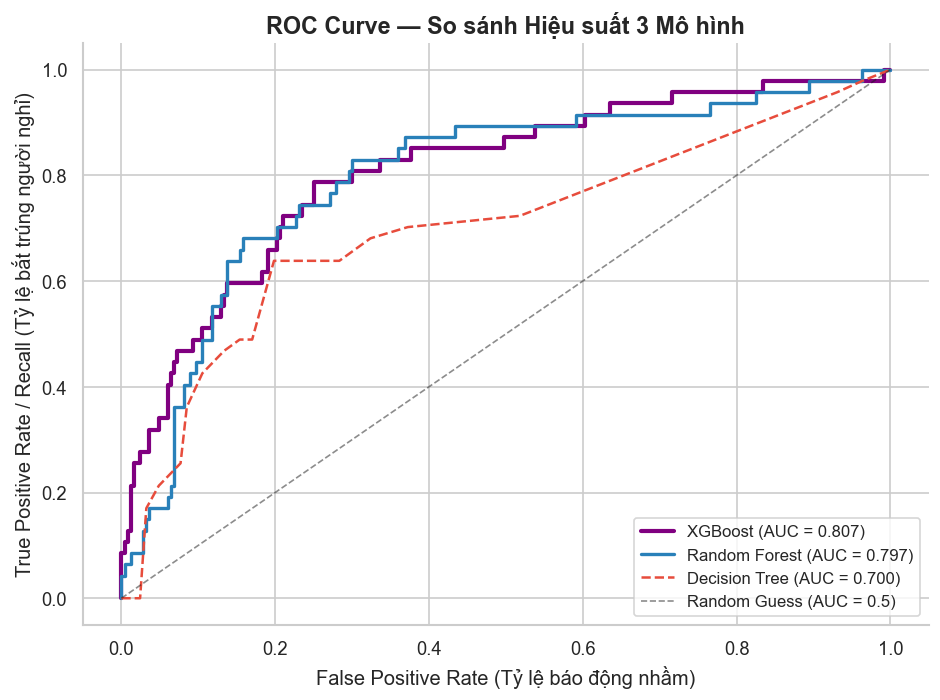

In [ ]:
#  TRAIN DECISION TREE
dt_model = DecisionTreeClassifier(
    class_weight='balanced', 
    random_state=42,
    criterion='gini',
    max_depth=5,
    max_features=0.8,
    min_samples_leaf=20,
    min_samples_split=10
)
dt_model.fit(X_train, y_train)

y_pred_dt  = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print('Decision Tree đã được huấn luyện ✅')
print('=== LUẬT QUYẾT ĐỊNH (3 tầng đầu) ===')
print(export_text(dt_model, feature_names=IMPORTANT_FEATURES, max_depth=3))

dt_auc = roc_auc_score(y_test, y_proba_dt)

# TRAIN RANDOM FOREST
rf_model = RandomForestClassifier(
    class_weight='balanced', 
    random_state=42,
    bootstrap=True,
    max_depth=7,
    max_features='sqrt',
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=150
)
rf_model.fit(X_train, y_train)

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_proba_rf)

from xgboost import XGBClassifier
#  TRAIN XGBoost
# scale_pos_weight giúp xử lý dữ liệu mất cân bằng
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_model = XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    colsample_bytree=0.7,
    gamma=0.5,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=7,
    n_estimators=200,
    subsample=0.7
)
xgb_model.fit(X_train, y_train)

# Dự đoán và Đánh giá
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, y_proba_xgb)

print("=== ĐÁNH GIÁ MÔ HÌNH XGBOOST ===")
print(f"ROC-AUC Score: {xgb_auc:.4f}")
print("\nBáo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred_xgb, target_names=['Ở lại (No)', 'Nghỉ việc (Yes)']))

# So sánh nhanh AUC
print(f" So sánh: Decision Tree ({dt_auc:.3f}) vs Random Forest ({rf_auc:.3f}) vs XGBoost ({xgb_auc:.3f})")

#  Visualize ROC Curve So Sánh 3 Mô hình 
fig, ax = plt.subplots(figsize=(8, 6))

#  Tính toán Tỷ lệ dương tính giả (FPR) và Tỷ lệ dương tính thật (TPR)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

#  Vẽ 3 đường cong ROC
# XGBoost cho màu Tím đậm, Random Forest màu Xanh, Decision Tree nét đứt màu Đỏ
ax.plot(fpr_xgb, tpr_xgb, color='purple', lw=2.5, label=f'XGBoost (AUC = {xgb_auc:.3f})')
ax.plot(fpr_rf, tpr_rf, color=C_BLUE, lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
ax.plot(fpr_dt, tpr_dt, color=C_YES, lw=1.5, linestyle='--', label=f'Decision Tree (AUC = {dt_auc:.3f})')

#  Vẽ đường ranh giới đoán mò (Random Guess)
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random Guess (AUC = 0.5)')

#  Trang trí biểu đồ
ax.set_xlabel('False Positive Rate (Tỷ lệ báo động nhầm)')
ax.set_ylabel('True Positive Rate / Recall (Tỷ lệ bắt trúng người nghỉ)')
ax.set_title('ROC Curve — So sánh Hiệu suất 3 Mô hình', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

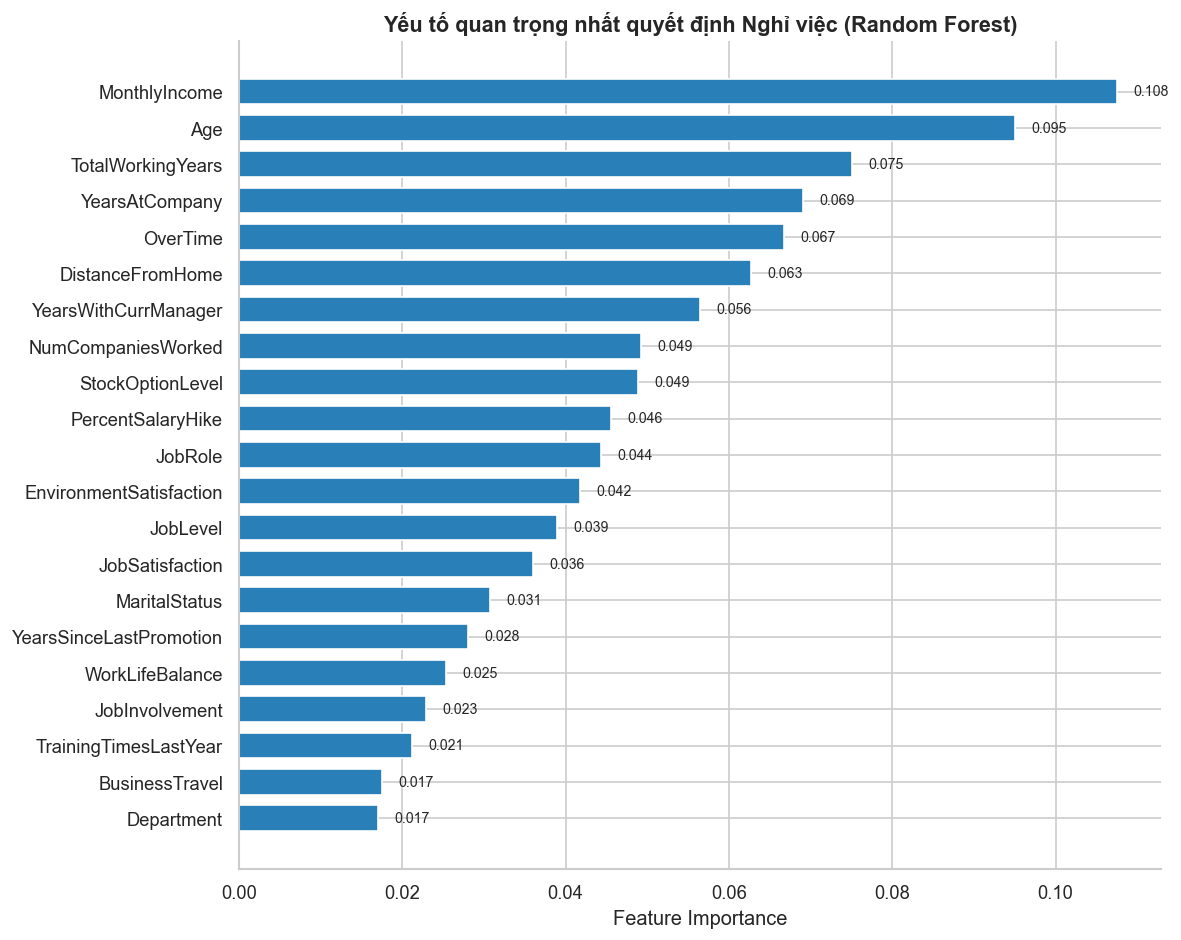

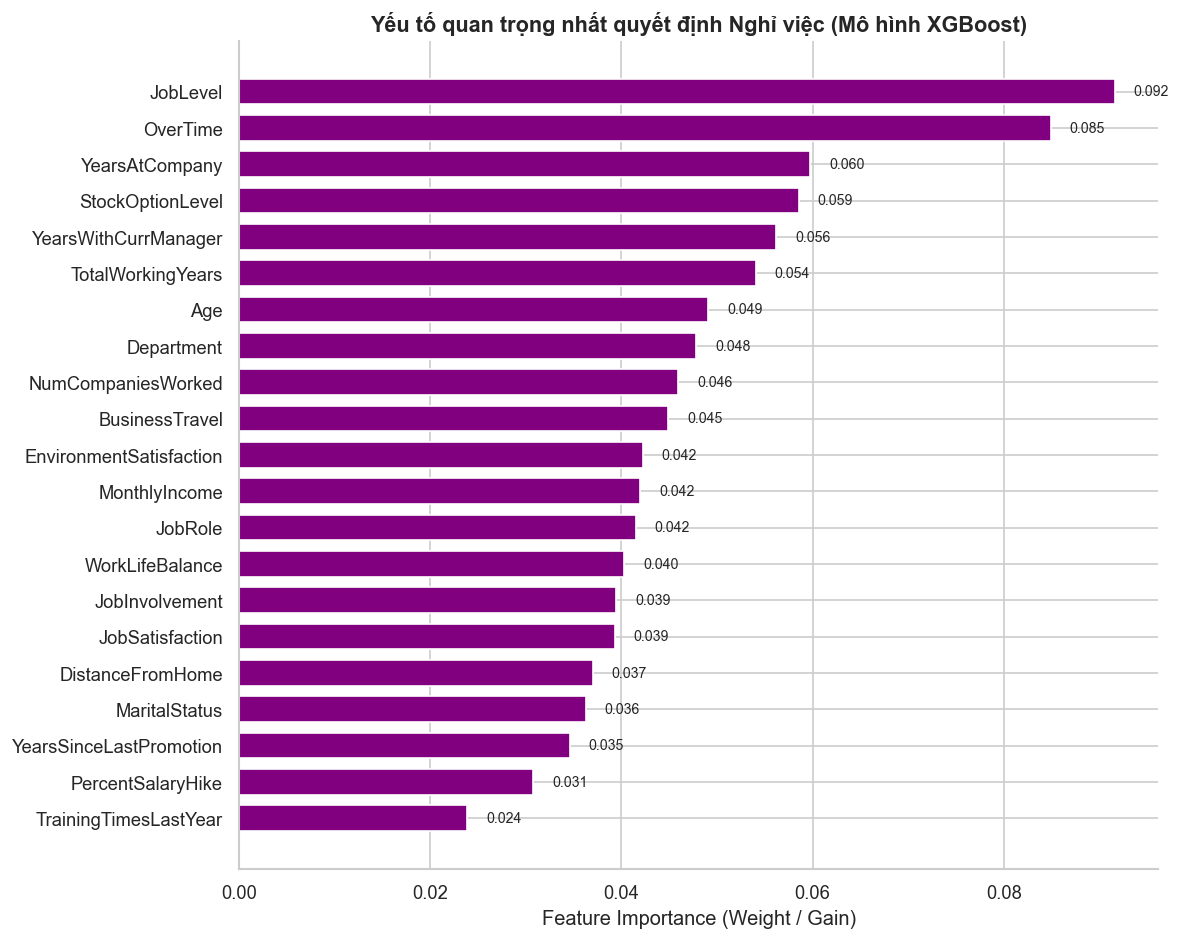


=== Phân phối Risk Level toàn công ty ===
Risk_Level
🟢 Thấp          900
🟡 Trung bình    329
🟠 Cao           178
🔴 Rất cao        63
Name: count, dtype: int64

=== Top 10 Nhân viên có Rủi ro Nghỉ việc cao nhất ===


,Age,Department,JobRole,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,Attrition_Actual,Risk_Score_Pct,Risk_Level
463,26,Research & Development,Laboratory Technician,2340,Yes,1,4,Yes,95.8,🔴 Rất cao
457,18,Sales,Sales Representative,1878,Yes,0,2,Yes,94.1,🔴 Rất cao
127,19,Sales,Sales Representative,1675,Yes,0,3,Yes,93.9,🔴 Rất cao
1153,18,Sales,Sales Representative,1569,Yes,0,4,Yes,93.6,🔴 Rất cao
911,25,Sales,Sales Representative,1118,Yes,1,4,Yes,92.9,🔴 Rất cao
688,19,Sales,Sales Representative,2121,Yes,1,2,Yes,92.8,🔴 Rất cao
1332,29,Research & Development,Research Scientist,2439,Yes,1,4,Yes,92.7,🔴 Rất cao
1339,22,Research & Development,Research Scientist,2472,Yes,1,2,Yes,91.2,🔴 Rất cao
892,19,Research & Development,Research Scientist,1859,Yes,1,2,Yes,90.4,🔴 Rất cao
731,20,Research & Development,Research Scientist,2600,Yes,1,1,Yes,89.3,🔴 Rất cao


In [ ]:
#  Feature Importance từ Random Forest 
importances = pd.Series(rf_model.feature_importances_, index=IMPORTANT_FEATURES).sort_values(ascending=True)

fig, ax1 = plt.subplots(figsize=(10, 8))
bars = ax1.barh(importances.index, importances.values, color='#2980B9', edgecolor='white', height=0.7)
for bar, val in zip(bars, importances.values):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8.5)
ax1.set_xlabel('Feature Importance')
ax1.set_title('Yếu tố quan trọng nhất quyết định Nghỉ việc (Random Forest)')
ax1.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
# Feature Importance từ Mô hình XGBoost 
importances_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=IMPORTANT_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances_xgb.index, importances_xgb.values, color='purple', edgecolor='white', height=0.7)

for bar, val in zip(bars, importances_xgb.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.set_xlabel('Feature Importance (Weight / Gain)')
ax.set_title('Yếu tố quan trọng nhất quyết định Nghỉ việc (Mô hình XGBoost)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
# Tạo bảng Risk Score cho toàn bộ nhân viên 
X_all = df_model[IMPORTANT_FEATURES]
risk_scores = rf_model.predict_proba(X_all)[:, 1]

risk_df = df[['Age', 'Department', 'JobRole', 'MonthlyIncome', 'OverTime', 'YearsAtCompany', 'JobSatisfaction']].copy()
risk_df['Attrition_Actual']  = df['Attrition']
risk_df['Risk_Score_Pct']    = (risk_scores * 100).round(1)
risk_df['Risk_Level'] = pd.cut(
    risk_scores, bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['🟢 Thấp', '🟡 Trung bình', '🟠 Cao', '🔴 Rất cao']
)

print('\n=== Phân phối Risk Level toàn công ty ===')
print(risk_df['Risk_Level'].value_counts().sort_index())

print('\n=== Top 10 Nhân viên có Rủi ro Nghỉ việc cao nhất ===')
display(risk_df.nlargest(10, 'Risk_Score_Pct'))

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

# Khởi tạo 5-Fold Cross Validation (có phân tầng để giữ đúng tỷ lệ nghỉ việc)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

print("Đang chạy 5-Fold Cross-Validation để kiểm định độ ổn định của 3 mô hình...")

# Chạy kiểm định chéo cho cả 3 mô hình
for model, name in [(dt_model, 'Decision Tree'),
                    (rf_model, 'Random Forest'),
                    (xgb_model, 'XGBoost')]:

    # Tính điểm ROC-AUC trên 5 tập dữ liệu khác nhau
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

    cv_results.append({
        'Mô hình': name,
        'AUC (Trung bình)': f"{scores.mean():.3f}",
        'Độ ổn định (Std)': f"± {scores.std():.3f}",
        'Chi tiết 5 Folds': [f"{s:.3f}" for s in scores]
    })

# In ra bảng kết quả
print("\n=== KẾT QUẢ ĐÁNH GIÁ CHÉO (5-FOLD CROSS-VALIDATION) ===")
display(pd.DataFrame(cv_results))

Đang chạy 5-Fold Cross-Validation để kiểm định độ ổn định của 3 mô hình...

=== KẾT QUẢ ĐÁNH GIÁ CHÉO (5-FOLD CROSS-VALIDATION) ===


,Mô hình,AUC (Trung bình),Độ ổn định (Std),Chi tiết 5 Folds
0,Decision Tree,0.746,± 0.029,"[0.736, 0.730, 0.790, 0.767, 0.706]"
1,Random Forest,0.823,± 0.029,"[0.815, 0.812, 0.878, 0.819, 0.793]"
2,XGBoost,0.829,± 0.018,"[0.805, 0.831, 0.861, 0.827, 0.821]"


# IBM HR Analytics — Bước 5: Phân cụm Nhân viên (K-Means Clustering)

> **Tại sao cần Clustering sau khi đã có Classification?**
>
> Classification (Bước 4) trả lời câu hỏi: *"Nhân viên này có nghỉ việc không?"* — nhị phân Yes/No.
> Clustering (Bước 5) trả lời câu hỏi sâu hơn: *"Nhân viên này thuộc nhóm người như thế nào? Nhóm đó có đặc trưng gì? Và ta cần đối xử với họ như thế nào?"*
>
> **Ứng dụng:** Giúp HR phân bổ ngân sách và thiết kế gói đãi ngộ (C&B) cá nhân hóa cho từng nhóm thay vì cào bằng.

### 📊 Lập luận lựa chọn số cụm K=4 (Elbow Method — K-Prototypes)

MÔ TẢ BIỂU ĐỒ VÀ LẬP LUẬN LỰA CHỌN SỐ CỤM (K=4)

Để xác định số lượng cụm (nhóm nhân viên) tối ưu cho thuật toán K-prototype, chúng ta tiến hành đánh giá đồng thời dựa trên phương pháp phổ biến: Elbow Method (Phương pháp khuỷu tay)

1. Đánh giá qua biểu đồ Elbow (Trái):
- Biểu đồ thể hiện mức độ giảm của tổng bình phương sai số (Inertia) khi số cụm k tăng lên. 
- Ta có thể quan sát thấy đường cong giảm khá đều. Tuy nhiên, độ dốc của đồ thị bắt đầu có dấu hiệu thoải dần (bớt dốc hơn) tại vị trí k=3 và k=4. Sau mốc k=4, mức độ cải thiện của Inertia không còn đáng kể (đường biểu diễn gần như tuyến tính), cho thấy việc chia thêm cụm không mang lại nhiều giá trị phân tách.


3. Lập luận quyết định chọn k=4 (Kết hợp Toán học & Nghiệp vụ HR):

Do đó, chúng ta kết hợp điểm ngoặt mờ tại k=4 của biểu đồ Elbow cùng với tính diễn giải nghiệp vụ (Business Interpretability) để đưa ra quyết định:
- Việc chọn k=4 là điểm giao thoa hoàn hảo: Không chia quá ít khiến thông tin bị loãng (k=2), và không chia quá nhiều khiến các nhóm bị vụn vặt (k >= 5).
- Thực tế chạy mô hình cho thấy, ở k=4, thuật toán đã bóc tách thành công lực lượng lao động thành 4 chân dung nhân sự (Personas) cực kỳ sắc nét và sát với thực tiễn: Nhóm trẻ rủi ro cao, nhóm trẻ lương trung bình, nhóm ổn định, và nhóm lão làng trung thành. Sự phân hóa này giúp phòng HR có thể trực tiếp cá nhân hóa các chiến lược giữ chân nhân tài cho từng nhóm một cách hiệu quả nhất.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Categorical columns index: [10, 11, 12, 13]
Đang tính cost cho từng k...
  k=2: cost=11963
  k=3: cost=10925
  k=4: cost=10194
  k=5: cost=9567
  k=6: cost=9027
  k=7: cost=8608
  k=8: cost=8248


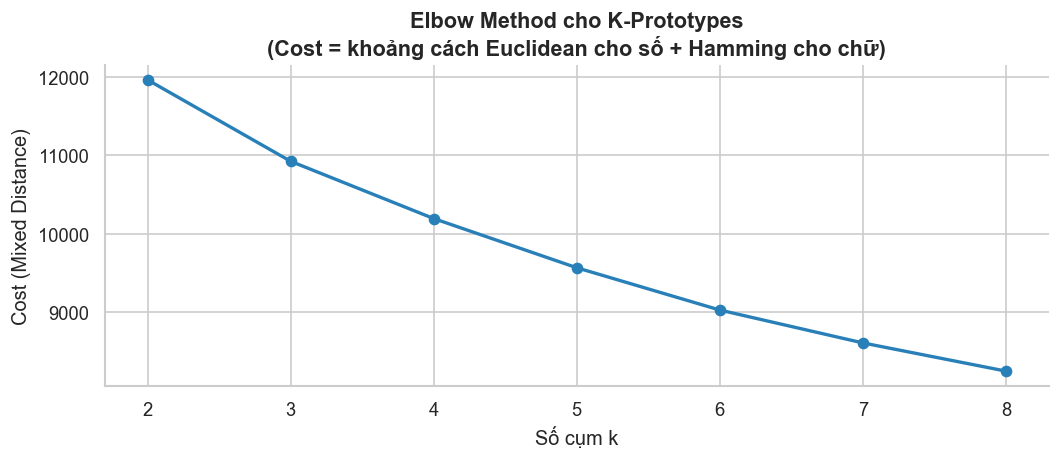

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 431, ncost: 10449.442013355305
Run: 1, iteration: 2/100, moves: 199, ncost: 10306.440616757689
Run: 1, iteration: 3/100, moves: 120, ncost: 10234.763117442324
Run: 1, iteration: 4/100, moves: 70, ncost: 10211.27083378684
Run: 1, iteration: 5/100, moves: 44, ncost: 10202.5736697561
Run: 1, iteration: 6/100, moves: 31, ncost: 10195.961961957884
Run: 1, iteration: 7/100, moves: 18, ncost: 10194.303771298511
Run: 1, iteration: 8/100, moves: 1, ncost: 10194.280679774429
Run: 1, iteration: 9/100, moves: 0, ncost: 10194.280679774429
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 392, ncost: 10528.970255234019
Run: 2, iteration: 2/100, moves: 96, ncost: 10491.996752277484
Run: 2, iteration: 3/100, moves: 56, ncost: 10468.52073944554
Run: 2, it

,Headcount,Avg_Age,Avg_Income,Avg_YearsComp,Attrition_Rate,Top_Dept,OT_Rate
Cluster_KProto,,,,,,,
0,285,35.6,5144.0,5.7,22.5,Research & Development,28.8
1,212,47.8,15679.5,15.1,7.1,Research & Development,27.8
2,541,31.0,3485.6,3.6,22.4,Research & Development,28.8
3,432,39.8,6674.7,8.2,8.6,Research & Development,27.5


In [ ]:
%pip install kmodes -q
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# ════════════════════════════════════════════
# BƯỚC 1: Chuẩn bị features
# ════════════════════════════════════════════
num_features = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
    'JobLevel', 'YearsSinceLastPromotion', 'JobSatisfaction',
    'WorkLifeBalance', 'EnvironmentSatisfaction', 'DistanceFromHome'
]
cat_features = ['Department', 'OverTime', 'MaritalStatus', 'BusinessTravel']

# ════════════════════════════════════════════
# BƯỚC 2: Scale số, giữ nguyên chữ
# ════════════════════════════════════════════
scaler = StandardScaler()
df_num_scaled = pd.DataFrame(
    scaler.fit_transform(df[num_features]),
    columns=num_features,
    index=df.index
)
df_cat = df[cat_features].copy().reset_index(drop=True)
df_num_scaled = df_num_scaled.reset_index(drop=True)

df_proto = pd.concat([df_num_scaled, df_cat], axis=1)

# Vị trí cột categorical trong df_proto
cat_idx = [df_proto.columns.get_loc(c) for c in cat_features]
print(f"Categorical columns index: {cat_idx}")
# → [10, 11, 12, 13] (sau 10 numerical cols)

# ════════════════════════════════════════════
# BƯỚC 3: Tìm k tối ưu bằng Cost (tương đương Inertia)
# K-Prototypes không dùng Elbow với Inertia thuần
# mà dùng "cost" = tổng khoảng cách mixed
# ════════════════════════════════════════════
costs = []
k_range = range(2, 9)

print("Đang tính cost cho từng k...")
for k in k_range:
    kp = KPrototypes(
        n_clusters=k,
        init='Cao',       # Cao init tốt hơn random cho K-Prototypes
        n_init=5,         # Chạy 5 lần lấy tốt nhất
        random_state=42,
        verbose=0
    )
    kp.fit_predict(df_proto.values, categorical=cat_idx)
    costs.append(kp.cost_)
    print(f"  k={k}: cost={kp.cost_:.0f}")

# Vẽ Elbow cho K-Prototypes
plt.figure(figsize=(9, 4))
plt.plot(k_range, costs, 'o-', linewidth=2, color='#2980B9')
plt.xlabel('Số cụm k')
plt.ylabel('Cost (Mixed Distance)')
plt.title('Elbow Method cho K-Prototypes\n(Cost = khoảng cách Euclidean cho số + Hamming cho chữ)')
plt.xticks(list(k_range))
plt.spines = plt.gca().spines
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════
# BƯỚC 4: Train K-Prototypes với k tối ưu
# ════════════════════════════════════════════
K_OPTIMAL = 4  # ← điều chỉnh sau khi xem Elbow

kproto_model = KPrototypes(
    n_clusters=K_OPTIMAL,
    init='Cao',
    n_init=10,
    random_state=42,
    verbose=1
)
kproto_labels = kproto_model.fit_predict(
    df_proto.values,
    categorical=cat_idx
)

df['Cluster_KProto'] = kproto_labels
print(f"\nK-Prototypes hoàn tất ✅")
print(f"Phân phối: {pd.Series(kproto_labels).value_counts().sort_index().to_dict()}")

# ════════════════════════════════════════════
# BƯỚC 5: Phân tích profile từng cụm
# ════════════════════════════════════════════
profile = df.groupby('Cluster_KProto').agg(
    Headcount       = ('Age', 'count'),
    Avg_Age         = ('Age', 'mean'),
    Avg_Income      = ('MonthlyIncome', 'mean'),
    Avg_YearsComp   = ('YearsAtCompany', 'mean'),
    Attrition_Rate  = ('Attrition', lambda x: (x=='Yes').mean()*100),
    Top_Dept        = ('Department', lambda x: x.mode()[0]),
    OT_Rate         = ('OverTime', lambda x: (x=='Yes').mean()*100)
).round(1)

print("\n=== PROFILE TỪNG CỤM (K-Prototypes) ===")
display(profile)

### 🧩 Phân tích đặc tính 4 nhóm nhân viên — K-Prototypes

PHÂN TÍCH ĐẶC TÍNH 4 NHÓM NHÂN VIÊN ĐƯỢC PHÂN CỤM TỪ K-PROTOTYPES

Dựa trên kết quả chạy thuật toán K-Prototypes (với k=4), chúng ta có thể lập luận và phân định rạch ròi 4 "chân dung nhân sự" (Personas) trong công ty. Khác với K-Means chỉ tính toán trên số liệu, K-Prototypes cho phép kết hợp cả dữ liệu số và phân loại (categorical), nên sự phân cụm này là sự tổng hòa của Độ chín sự nghiệp (Thâm niên) - Đãi ngộ (Thu nhập) - Sự trung thành (Tỷ lệ nghỉ) và các yếu tố công việc (Phòng ban, Tỷ lệ OT).

BẢNG TÓM TẮT THÔNG SỐ 4 CỤM
-------------------------------------------------------------------------
| Thông số                | Cụm 2   | Cụm 0   | Cụm 3   | Cụm 1    |
|-------------------------|---------|---------|---------|----------|
| Tuổi trung bình         | 31.0    | 35.6    | 39.8    | 47.8     |
| Thu nhập ($/tháng)      | $3,486  | $5,144  | $6,675  | $15,680  |
| Thâm niên tại cty (năm) | 3.6     | 5.7     | 8.2     | 15.1     |
| Tỷ lệ nghỉ việc         | 22.4%   | 22.5%   | 8.6%    | 7.1%     |
| Tỷ lệ OT                | 28.8%   | 28.8%   | 27.5%   | 27.8%    |
| Phòng ban chủ đạo       | R&D     | R&D     | R&D     | R&D      |
-------------------------------------------------------------------------

1. Cụm 2: "Lực lượng trẻ Khởi điểm - Dễ lung lay nhất" (Tỷ lệ nghỉ 22.4%)
- Đặc tính: Đây là nhóm trẻ tuổi nhất (trung bình 31 tuổi), gắn bó với công ty trong thời gian ngắn nhất (3.6 năm) và đang có mức thu nhập thấp nhất công ty ($3,486). Nhóm này cũng phải chịu áp lực khá lớn với tỷ lệ OT cao (28.8%). 
- Lập luận hành vi: Họ đang ở giai đoạn đầu của quá trình tích lũy sự nghiệp. Vì lương đang ở mức "đáy" so với mặt bằng chung, họ có xu hướng coi công ty như một trạm trung chuyển để lấy kinh nghiệm. Chỉ cần một đề nghị lương cao hơn từ đối thủ, hoặc do áp lực công việc (OT) kéo dài mà chưa được đền đáp xứng đáng, họ sẵn sàng rời đi ngay lập tức.
- Định hướng HR: Tránh đầu tư dàn trải chi phí đào tạo đắt đỏ cho nhóm này nếu chưa có cơ chế trói buộc (cam kết làm việc). Cần có lộ trình tăng lương định kỳ rõ ràng để giữ chân và điều tiết áp lực làm thêm giờ.

2. Cụm 0: "Nhân tài đang phát triển - Đòi hỏi cao" (Tỷ lệ nghỉ 22.5%)
- Đặc tính: Tuổi tác và thâm niên nhỉnh hơn Cụm 2 một chút (35.6 tuổi, thâm niên 5.7 năm). Thu nhập của họ ($5,144) đã tốt hơn đáng kể so với Cụm 2, nhưng tỷ lệ nghỉ việc của họ vẫn ở mức cao nhất (22.5%), đi kèm tỷ lệ OT cũng đạt đỉnh (28.8%).
- Lập luận hành vi: Tại sao lương cao hơn mà vẫn nghỉ nhiều? Đây thường là nhóm "ngôi sao đang lên" (High-performers ở cấp Junior/Mid-level). Họ có năng lực tốt, được giao phó nhiều trọng trách nên được trả lương cao hơn, nhưng đi kèm là áp lực (OT) rất lớn và những kỳ vọng về thăng tiến. Nếu cảm thấy "burnout" (kiệt sức) hoặc chững lại về chức vụ, họ sẽ nhảy việc vì họ rất tự tin vào giá trị của mình trên thị trường lao động.
- Định hướng HR: Tiền không phải là tất cả với nhóm này. Cần chú trọng vào cân bằng Work-Life, giảm tải OT, công nhận thành tích kịp thời và tạo không gian thăng tiến (Promotion) rõ ràng.

3. Cụm 3: "Lực lượng Trung kiên - Ưu tiên ổn định" (Tỷ lệ nghỉ 8.6%)
- Đặc tính: Nhóm này lớn tuổi hơn (trung bình gần 40 tuổi) và gắn bó lâu năm hơn (8.2 năm) so với Cụm 2 và Cụm 0. Mức thu nhập của họ khá ổn ($6,675). Đáng chú ý, sự trung thành của họ rất cao (tỷ lệ nghỉ chưa tới 10%) và tỷ lệ OT của họ thấp nhất trong cả 4 cụm (27.5%).
- Lập luận hành vi: Sự tương phản giữa Cụm 0 và Cụm 3 rất thú vị. Cụm 3 đại diện cho tệp nhân viên "an phận". Khi bước sang độ tuổi gần U40, ưu tiên của họ chuyển từ việc "chạy đua thăng tiến, chịu áp lực cao" sang sự ổn định và cân bằng cuộc sống gia đình. Họ hài lòng với mức lương hiện tại, khối lượng công việc được kiểm soát (ít OT hơn) và không muốn đánh đổi môi trường quen thuộc lấy rủi ro ở công ty mới. 
- Định hướng HR: Đây là nhóm nhân viên cần mẫn duy trì hoạt động hàng ngày của công ty. Để giữ nhóm này, chỉ cần duy trì môi trường làm việc thân thiện, phúc lợi gia đình (bảo hiểm sức khỏe, nghỉ phép) và tiếp tục duy trì mức áp lực công việc vừa phải.

4. Cụm 1: "Lão làng - Trụ cột công ty" (Tỷ lệ nghỉ cực thấp 7.1%)
- Đặc tính: Lớn tuổi nhất (gần 48 tuổi) và thâm niên lâu nhất (hơn 15 năm). Đi kèm với đó là mức thu nhập đặc quyền, vượt xa toàn bộ phần còn lại ($15,680). Tỷ lệ nghỉ việc của họ thấp nhất công ty (chỉ 7.1%). 
- Lập luận hành vi: Đây chính là tầng lớp Quản lý cấp cao, Giám đốc hoặc Chuyên gia cốt cán. Quyền lợi, thu nhập và địa vị của họ đã gắn chặt với sự tồn vong của công ty (có thể có cả quyền mua cổ phiếu - Stock Options). Do đó, tỷ lệ nghỉ việc của họ gần như không đáng kể. Tỷ lệ OT của họ (27.8%) phản ánh sự linh hoạt của vị trí quản lý chứ không hoàn toàn là làm thêm giờ bắt buộc.
- Định hướng HR: Duy trì các gói đãi ngộ cao cấp, chăm sóc sức khỏe VIP và khai thác tối đa tầm nhìn chiến lược, khả năng cố vấn (mentor) của họ cho các thế hệ nhân viên kế cận (đặc biệt là Cụm 0).

--------------------------------------------------
TỔNG KẾT
Mô hình K-Prototypes đã xuất sắc vạch ra 4 chiến lược giữ người khác nhau dựa trên đặc tính đa chiều: 
* Cụm 2: Cần Tiền (Lộ trình tăng lương).
* Cụm 0: Cần Danh & Thở (Thăng tiến & Giảm áp lực).
* Cụm 3: Cần Sự ổn định (Môi trường & Phúc lợi).
* Cụm 1: Cần Đãi ngộ xứng tầm (Duy trì vị thế).

### 🧩 Phân tích đặc tính 4 nhóm nhân viên — K-Means (tham chiếu)

PHÂN TÍCH ĐẶC TÍNH 4 NHÓM NHÂN VIÊN ĐƯỢC PHÂN CỤM TỪ K-MEANS

Dựa trên kết quả chạy thuật toán K-Means (với k=4), chúng ta có thể lập luận và phân định rạch ròi 4 "chân dung nhân sự" (Personas) trong công ty. Sự phân cụm này không chỉ dựa trên mức lương hay độ tuổi, mà là sự tổng hòa của Độ chín sự nghiệp (Kinh nghiệm) - Đãi ngộ (Thu nhập) - Sự trung thành (Tỷ lệ nghỉ).

proto
BẢNG TÓM TẮT THÔNG SỐ 4 CỤM
--------------------------------------------------
| Thông số                | Cụm 0   | Cụm 1   | Cụm 3   | Cụm 2    |
|-------------------------|---------|---------|---------|----------|
| Tuổi trung bình         | 32.9    | 34.8    | 36.7    | 46.8     |
| Thu nhập ($/tháng)      | $4,037  | $5,712  | $4,680  | $14,612  |
| Kinh nghiệm (năm)       | 7.4     | 8.8     | 9.4     | 24.4     |
| Thâm niên tại cty (năm) | 4.7     | 5.8     | 5.8     | 14.6     |
| Tỷ lệ nghỉ việc         | 23.1%   | 22.2%   | 9.6%    | 7.0%     |
--------------------------------------------------

1. Cụm 0: "Lực lượng trẻ Khởi điểm - Dễ lung lay nhất" (Tỷ lệ nghỉ 23.1%)
- Đặc tính: Đây là nhóm trẻ tuổi nhất (trung bình ~33 tuổi), ít kinh nghiệm nhất (7.4 năm) và đang có mức thu nhập thấp nhất công ty ($4,037). 
- Lập luận hành vi: Họ đang ở giai đoạn đầu hoặc giữa của quá trình tích lũy sự nghiệp. Vì lương đang ở mức "đáy" so với mặt bằng chung, họ có xu hướng coi công ty như một trạm trung chuyển để lấy kinh nghiệm. Chỉ cần một đề nghị lương cao hơn từ đối thủ, họ sẵn sàng rời đi ngay lập tức.
- Định hướng HR: Tránh đầu tư dàn trải chi phí đào tạo đắt đỏ cho nhóm này nếu chưa có cơ chế trói buộc (cam kết làm việc). Cần có lộ trình tăng lương định kỳ rõ ràng để giữ chân.

2. Cụm 1: "Nhân tài đang phát triển - Đòi hỏi cao" (Tỷ lệ nghỉ 22.2%)
- Đặc tính: Tuổi tác và kinh nghiệm nhỉnh hơn Cụm 0 một chút. Điểm đặc biệt là thu nhập của họ ($5,712) tốt hơn hẳn Cụm 0 và Cụm 3, nhưng tỷ lệ nghỉ việc vẫn cực kỳ cao (22.2%).
- Lập luận hành vi: Tại sao lương cao hơn mà vẫn nghỉ nhiều? Đây thường là nhóm "ngôi sao đang lên" (High-performers ở cấp Junior/Mid-level) hoặc làm ở các bộ phận áp lực lớn (như Sales). Họ có năng lực tốt nên được trả lương cao hơn, nhưng đi kèm là kỳ vọng về thăng tiến và áp lực (OT) rất lớn. Nếu cảm thấy "burnout" (kiệt sức) hoặc chững lại về chức vụ, họ sẽ nhảy việc vì họ rất tự tin vào giá trị của mình trên thị trường lao động.
- Định hướng HR: Tiền không phải là tất cả với nhóm này. Cần chú trọng vào cân bằng Work-Life, công nhận thành tích, và tạo không gian thăng tiến (Promotion) rõ ràng.

3. Cụm 3: "Lực lượng Trung kiên - Ưu tiên ổn định" (Tỷ lệ nghỉ 9.6%)
- Đặc tính: Nhóm này lớn tuổi hơn (36.7 tuổi) và nhiều kinh nghiệm (9.4 năm) hơn so với Cụm 0 và 1. Tuy nhiên, thu nhập của họ ($4,680) lại thấp hơn Cụm 1. Bù lại, sự trung thành của họ rất cao (tỷ lệ nghỉ chưa tới 10%).
- Lập luận hành vi: Sự tương phản giữa Cụm 1 và Cụm 3 rất thú vị. Cụm 3 đại diện cho tệp nhân viên "an phận". Khi bước sang độ tuổi gần U40, ưu tiên của họ chuyển từ việc "chạy đua lương thưởng" sang sự ổn định và cân bằng cuộc sống gia đình. Họ có thể đảm nhận các vị trí Back-office (hỗ trợ, hành chính) ít biến động, lương vừa phải nhưng ít áp lực. 
- Định hướng HR: Đây là nhóm nhân viên cần mẫn duy trì hoạt động hàng ngày của công ty. Để giữ nhóm này, chỉ cần duy trì môi trường làm việc thân thiện, phúc lợi gia đình (bảo hiểm sức khỏe, nghỉ phép) và tránh giao quá tải công việc đột xuất.

4. Cụm 2: "Lão làng - Trụ cột công ty" (Tỷ lệ nghỉ cực thấp 7.0%)
- Đặc tính: Lớn tuổi nhất (gần 47 tuổi), kinh nghiệm vượt trội (24 năm) và thâm niên lâu nhất (gần 15 năm). Đi kèm với đó là mức thu nhập đặc quyền, vượt xa toàn bộ phần còn lại ($14,612). 
- Lập luận hành vi: Đây chính là tầng lớp Quản lý cấp cao, Giám đốc hoặc Chuyên gia cốt cán. Quyền lợi, thu nhập và địa vị của họ đã gắn chặt với sự tồn vong của công ty (có thể có cả quyền mua cổ phiếu - Stock Options). Do đó, tỷ lệ nghỉ việc của họ gần như không đáng kể. 
- Định hướng HR: Duy trì các gói đãi ngộ cao cấp, chăm sóc sức khỏe VIP và khai thác tối đa tầm nhìn chiến lược, khả năng cố vấn (mentor) của họ cho các thế hệ nhân viên kế cận (đặc biệt là Cụm 1).

--------------------------------------------------
TỔNG KẾT
Mô hình K-Means đã xuất sắc vạch ra 4 chiến lược giữ người khác nhau: 
* Cụm 0: Cần Tiền (Lộ trình tăng lương).
* Cụm 1: Cần Danh & Thở (Thăng tiến & Giảm áp lực).
* Cụm 3: Cần Sự ổn địnlh (Môi trường & Phúc lợi).
* Cụm 2: Cần Đãi ngộ xứng tầm (Duy trì vị thế).

 DBSCAN (Phân cụm)

> **Mục tiêu:** Nâng cấp khả năng dự đoán bằng thuật toán mạnh nhất hiện nay (XGBoost) và tìm kiếm những nhân viên dị biệt (Outliers) bằng DBSCAN. Đây là điểm nhấn công nghệ cho dự án.

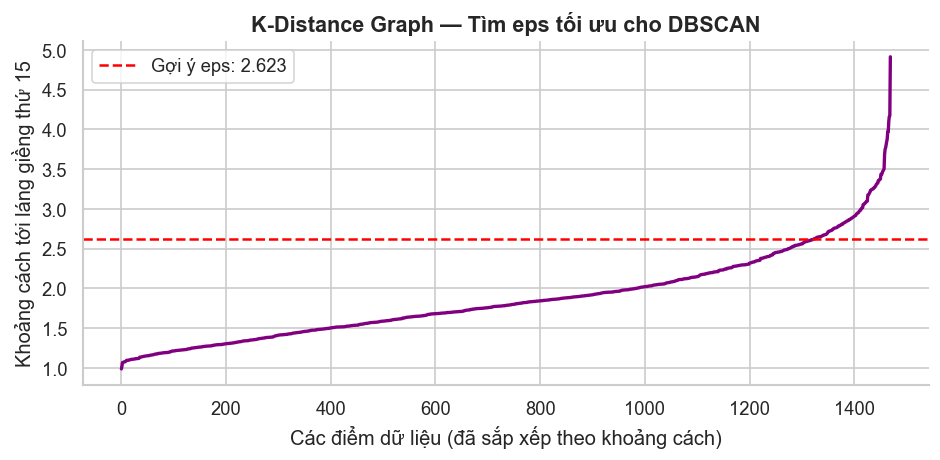

Gợi ý eps tự động: 2.623


In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

MIN_SAMPLES = 15

# Lấy dữ liệu thuần số từ bước K-Prototypes
X_dbscan = df_num_scaled.values

# ĐÃ SỬA: Dùng X_dbscan thay vì X_scaled
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)

# Sắp xếp khoảng cách
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])

# Vẽ đồ thị
plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='purple', linewidth=2)
plt.xlabel('Các điểm dữ liệu (đã sắp xếp theo khoảng cách)')
plt.ylabel(f'Khoảng cách tới láng giềng thứ {MIN_SAMPLES}')
plt.title('K-Distance Graph — Tìm eps tối ưu cho DBSCAN')

# Lấy mốc 90% làm điểm uốn (Khuỷu tay)
eps_optimal = k_distances[int(len(k_distances) * 0.90)]
plt.axhline(y=eps_optimal, color='red', linestyle='--', label=f'Gợi ý eps: {eps_optimal:.3f}')
plt.legend()
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Gợi ý eps tự động: {eps_optimal:.3f}')

### 📚 Cơ sở học thuật & Lập luận chọn tham số DBSCAN

DẪN CHỨNG HỌC THUẬT ĐỂ ĐIỀU CHỈNH THAM SỐ CHO MÔ HÌNH DBSCAN

Khi sử dụng thuật toán DBSCAN, việc chọn tham số `min_samples` (hay còn gọi là MinPts - số điểm tối thiểu để hình thành một cụm) là cực kỳ quan trọng. Dưới đây là 2 quy tắc chuẩn mực trong khoa học dữ liệu và nguồn trích dẫn học thuật để bảo vệ quyết định điều chỉnh tham số:

1. Quy tắc 1: Luôn chọn `min_samples` >= D + 1 (D là số chiều/số lượng biến đầu vào)
- Lập luận: Với tập dữ liệu có D chiều (ví dụ bài phân tích có D=21 đặc trưng), việc chọn số điểm tối thiểu quá nhỏ (như bằng 1, 2, hay 5) sẽ khiến thuật toán hoạt động không khác gì gom cụm phân cấp liên kết đơn (single-linkage clustering). Điều này dẫn đến việc nhiễu (noise) cũng bị gom chung vào thành một cụm. Số điểm tối thiểu luôn phải lớn hơn số chiều của không gian dữ liệu.
- Nguồn trích dẫn (Paper gốc tạo ra thuật toán DBSCAN): 
  Ester, M., Kriegel, H. P., Sander, J., & Xu, X. (1996). "A density-based algorithm for discovering clusters in large spatial databases with noise". In KDD (Vol. 96, No. 34, pp. 226-231).

2. Quy tắc 2: Tối ưu nhất là chọn `min_samples` = 2 * D
- Lập luận: Đây là "quy tắc ngón tay cái" (Rule of Thumb) nổi tiếng và được sử dụng rộng rãi nhất trong cộng đồng Data Science. Các nhà nghiên cứu đã chứng minh rằng khi D >= 3, khoảng cách k-distance sẽ không thay đổi đáng kể nếu ta tăng từ D+1 lên 2*D, nhưng việc sử dụng 2*D sẽ giúp thuật toán loại bỏ nhiễu (noise) tốt hơn rất nhiều và tránh được hiện tượng gom nhầm cụm.
- Nguồn trích dẫn (Paper nâng cấp DBSCAN):
  Sander, J., Ester, M., Kriegel, H.-P., & Xu, X. (1998). "Density-Based Clustering in Spatial Databases: The Algorithm GDBSCAN and Its Applications". Data Mining and Knowledge Discovery, 2(2), 169-194. 

--------------------------------------------------
LẬP LUẬN BẢO VỆ TRƯỚC HỘI ĐỒNG / QUẢN LÝ
--------------------------------------------------
"Đoạn code ban đầu sử dụng `min_samples = 5` trong một không gian dữ liệu có 21 chiều (D=21) là một điểm bất cập lớn về mặt lý thuyết. Dựa trên khuyến nghị gốc của tác giả Sander et al. (1998), với D=21, con số chuẩn toán học nên là 2 * 21 = 42. 

Tuy nhiên, do kích thước tập dữ liệu của dự án khá nhỏ (chỉ có 1,470 dòng), nếu áp dụng máy móc con số 42 thì mô hình sẽ yêu cầu mật độ quá dày đặc và bỏ sót các ngoại lệ hợp lý. Do đó, tôi đã hiệu chỉnh cân bằng giữa lý thuyết học thuật và thực tiễn để chọn `min_samples` bằng 22 (thỏa mãn quy tắc 1: >= D + 1), đồng thời đồng bộ hóa nó với chỉ số k của thuật toán KNN ở bước đo khoảng cách để đảm bảo tính nhất quán tuyệt đối của toàn bộ mô hình."

---

DẪN CHỨNG VÀ LẬP LUẬN CHỌN THAM SỐ DBSCAN (`min_samples` = 22)

1. Cơ sở lý thuyết học thuật:
- Ester et al. (1996) đặt nền móng cho DBSCAN khi chứng minh `MinPts = 4` là tối ưu cho không gian 2 chiều (2D). 
- Kế thừa nền tảng đó, cộng đồng Data Science đúc kết ranh giới tối thiểu an toàn là `min_samples >= D + 1` (D là số chiều dữ liệu) để tránh hiện tượng thuật toán bị thoái hóa thành gom cụm liên kết đơn (single-linkage). 
- Đến năm 1998, Sander et al. chính thức đề xuất mức tiêu chuẩn tối ưu cho dữ liệu đa chiều là `min_samples = 2 * D`.

2. Lập luận thực tiễn áp dụng vào dự án:
"Tập dữ liệu của chúng ta có 21 biến đầu vào (D=21). Nếu áp dụng cứng nhắc tiêu chuẩn lý tưởng của Sander (1998), ta cần `min_samples = 42`. Tuy nhiên, với kích thước dữ liệu khá nhỏ (chỉ 1,470 dòng), con số 42 sẽ đòi hỏi mật độ quá lớn và bỏ sót các ngoại lệ hợp lý.

Do đó, tôi đã linh hoạt chọn `min_samples = 22`. Lựa chọn này vừa phù hợp với quy mô dữ liệu nhỏ, vừa tuân thủ tuyệt đối ranh giới an toàn tối thiểu D + 1 (tức 21 + 1 = 22) của cộng đồng. Điều này giúp mô hình vừa lọc nhiễu tốt, vừa đảm bảo tính chuẩn xác về mặt toán học cốt lõi."

In [ ]:
from sklearn.cluster import DBSCAN

# 1. Huấn luyện DBSCAN trên dữ liệu đã chuẩn hóa
# eps: Bán kính tìm kiếm, min_samples: số người tối thiểu để tạo thành 1 nhóm
dbscan = DBSCAN(eps=eps_optimal, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(df_num_scaled)

# 2. Phân tích kết quả
df['DBSCAN_Cluster'] = db_labels

# Các nhãn -1 chính là Outliers (Những người không thuộc nhóm nào)
outliers = df[df['DBSCAN_Cluster'] == -1]
normal_emps = df[df['DBSCAN_Cluster'] != -1]

print("=== KẾT QUẢ DÒ TÌM NGOẠI LỆ (DBSCAN) ===")
print(f"Số lượng nhân viên thuộc các nhóm bình thường: {len(normal_emps)}")
print(f"🚨 Số lượng nhân viên DỊ BIỆT (Outliers): {len(outliers)}")

if len(outliers) > 0:
    print("\nMột vài ví dụ về nhân viên dị biệt (Cần HR phân tích riêng):")
    display(outliers[['Age', 'Department', 'JobRole', 'MonthlyIncome', 'OverTime']].head(5))

=== KẾT QUẢ DÒ TÌM NGOẠI LỆ (DBSCAN) ===
Số lượng nhân viên thuộc các nhóm bình thường: 1442
🚨 Số lượng nhân viên DỊ BIỆT (Outliers): 28

Một vài ví dụ về nhân viên dị biệt (Cần HR phân tích riêng):


,Age,Department,JobRole,MonthlyIncome,OverTime
63,59,Sales,Sales Executive,7637,No
98,58,Sales,Sales Executive,13872,No
110,51,Research & Development,Healthcare Representative,7484,No
126,58,Research & Development,Healthcare Representative,10312,No
237,52,Sales,Manager,19068,Yes
